# CT Poisson transmission on Tuolumne: SMC vs. baselines

This version is hardened for the Tuolumne/ROCm environment.

It fixes four common failure modes in the original notebook:

1. the checkpoint path no longer points to `/usr/workspace/...`;
2. the local `ct_*.py` modules are located explicitly through `CT_CODE_DIR`;
3. `surrogate_mode="none"` really skips the expensive tail-statistics pass;
4. DPS and posterior-quality score evaluations are chunked to avoid GPU-memory spikes.

Forward model:

$$a(x)=s\,\operatorname{link}(g(x+c)),\qquad
z=A_\Omega a(x),\qquad
\lambda=N_0e^{-z}+b,\qquad
y_i\sim\operatorname{Poisson}(\lambda_i).$$

Run **Config → Setup → Data → Diagnostics** first.  Do not start the samplers
until the checkpoint, module paths, gradient check, and fingerprint all print
successfully.


This self-contained edition embeds the four CT helper modules and writes them locally if they are not already present.


In [1]:
# ============================================================
# Actual five-level CT-SMC configuration
# ============================================================

import math
import os

os.environ["CT_RUN_MODE"] = "full"

# Same pretrained unconditional prior used to build the saved tail statistics.
os.environ["CT_CHECKPOINT_PATH"] = (
    "/p/lustre5/wang161/"
    "smc_swissroll_tuolumne/notebooks/"
    "MRISythetic/DOLCE_GaussianCT/prior/"
    "mri_score_prior_dsm2000_outputs/"
    "score_prior_singlecoil_mri_64_dsm2000_trained.pt"
)

# Directory containing the same checkpoint and tail statistics.
os.environ["CT_PRIOR_DIR"] = (
    "/p/lustre5/wang161/"
    "smc_swissroll_tuolumne/notebooks/"
    "MRISythetic/DOLCE_GaussianCT/prior/"
    "mri_score_prior_dsm2000_outputs"
)

# Previously computed prior-only tail statistics.
os.environ["CT_TAIL_STATS_PATH"] = (
    "/p/lustre5/wang161/"
    "smc_swissroll_tuolumne/notebooks/"
    "MRISythetic/DOLCE_GaussianCT/prior/"
    "mri_score_prior_dsm2000_outputs/"
    "score_prior_tail_behavior_stats.npz"
)

# ------------------------------------------------------------
# Normalized affine attenuation map
# ------------------------------------------------------------
# Match the affine slope to the secant slope of the original softplus map
# over the trained image range x in [-1, 1].  Do NOT redefine Cfg here.
softplus_scale = 0.05
softplus_gain = 1.0
softplus_offset = 2.0
x_low = -1.0
x_high = 1.0


def scalar_softplus(t: float) -> float:
    return math.log1p(math.exp(t))


a_low = softplus_scale * scalar_softplus(
    softplus_gain * (x_low + softplus_offset)
)
a_high = softplus_scale * scalar_softplus(
    softplus_gain * (x_high + softplus_offset)
)
normalized_affine_scale = (a_high - a_low) / (x_high - x_low)

os.environ["CT_ATTENUATION_LINK"] = "affine"
os.environ["CT_ATTENUATION_SCALE"] = repr(normalized_affine_scale)
os.environ["CT_ATTENUATION_GAIN"] = "1.0"
os.environ["CT_ATTENUATION_OFFSET"] = "1.0"  # x=-1 maps to attenuation 0

print("Matched normalized affine scale:", normalized_affine_scale)

# Restore the manuscript multiscale hierarchy.
os.environ["CT_SMC_LEVELS"] = "5"
os.environ["CT_SMC_REF_LEVELS"] = "8"

# Actually use mu_tail and eta.
os.environ["CT_SMC_SURROGATE"] = "inv_m"
# Alternatively:
# os.environ["CT_SMC_SURROGATE"] = "none"

# Choose the desired particle target.
os.environ["CT_N_SAMPLES"] = "600"
# For the paper-scale run:
# os.environ["CT_N_SAMPLES"] = "3000"

# Exact likelihood rather than automatic ESS-based likelihood tempering.
os.environ["CT_AUTO_CALIBRATE_STRENGTH"] = "0"
os.environ["CT_LIKELIHOOD_STRENGTH"] = "1.0"

# Full CT experiment.
os.environ["CT_NUM_ANGLES"] = "64"
os.environ["CT_NUM_DETECTORS"] = "64"
os.environ["CT_DPS_STEPS"] = "240"

os.environ["CT_RUN_POSTERIOR_QUALITY"] = "1"


Matched normalized affine scale: 0.04338314160138798


## 1. Configuration

Everything tunable lives here. No environment variables.

In [2]:
# ============================================================
# Self-contained CT helper-module bootstrap for Tuolumne
# ============================================================
# If CT_CODE_DIR is explicitly set, that complete helper directory is used.
# Otherwise the exact bundled helper sources below are written to a local
# _ct_helpers_embedded directory. This keeps the notebook self-contained and
# prevents stale helper files from a previous run from being imported.

import os
import pathlib

_CT_REQUIRED = ["ct_common.py", "ct_forward.py", "ct_smc.py", "ct_metrics.py"]
_CT_PROJECT_ROOT = pathlib.Path("/p/lustre5/wang161/smc_swissroll_tuolumne")

def _ct_dir_is_complete(path):
    path = pathlib.Path(path).expanduser()
    return path.is_dir() and all((path / name).is_file() for name in _CT_REQUIRED)

_embedded_sources = {'ct_common.py': '"""Score-prior network and VP-SDE helpers.\n'
                 '\n'
                 'Extracted VERBATIM from the SMC notebook so the CT experiment loads the same\n'
                 "architecture the checkpoint was trained with.  Do not edit: if the notebook's\n"
                 'model changes, re-extract rather than hand-patching.\n'
                 '\n'
                 'Forward SDE (as used throughout):   x_t = (1-t) x_0 + sqrt(t(2-t)) eps\n'
                 '"""\n'
                 '\n'
                 'import math\n'
                 'import numpy as np\n'
                 'import torch\n'
                 'import torch.nn as nn\n'
                 'import torch.nn.functional as F\n'
                 'from torch.utils.data import Dataset\n'
                 '\n'
                 'class SinusoidalTimeEmbedding(nn.Module):\n'
                 '    def __init__(self, dim: int):\n'
                 '        super().__init__()\n'
                 '        self.dim = int(dim)\n'
                 '\n'
                 '    def forward(self, t: torch.Tensor) -> torch.Tensor:\n'
                 '        # t: (B,)\n'
                 '        half = self.dim // 2\n'
                 '        device = t.device\n'
                 '        freqs = torch.exp(torch.linspace(math.log(1.0), math.log(1000.0), half, device=device))\n'
                 '        args = t[:, None] * freqs[None, :]\n'
                 '        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)\n'
                 '        if emb.shape[-1] < self.dim:\n'
                 '            emb = F.pad(emb, (0, self.dim - emb.shape[-1]))\n'
                 '        return emb\n'
                 '\n'
                 '\n'
                 'class TimeBlock(nn.Module):\n'
                 '    def __init__(self, in_ch: int, out_ch: int, emb_dim: int):\n'
                 '        super().__init__()\n'
                 '        groups = 8 if out_ch % 8 == 0 else 1\n'
                 '        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)\n'
                 '        self.norm1 = nn.GroupNorm(groups, out_ch)\n'
                 '        self.emb_proj = nn.Linear(emb_dim, out_ch)\n'
                 '        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)\n'
                 '        self.norm2 = nn.GroupNorm(groups, out_ch)\n'
                 '        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()\n'
                 '\n'
                 '    def forward(self, x, emb):\n'
                 '        h = self.conv1(x)\n'
                 '        h = self.norm1(h)\n'
                 '        h = F.silu(h)\n'
                 '        h = h + self.emb_proj(emb)[:, :, None, None]\n'
                 '        h = self.conv2(h)\n'
                 '        h = self.norm2(h)\n'
                 '        h = F.silu(h)\n'
                 '        return h + self.skip(x)\n'
                 '\n'
                 '\n'
                 'class SmallUNetScore(nn.Module):\n'
                 '    def __init__(self, in_ch=1, base_ch=32, emb_dim=128):\n'
                 '        super().__init__()\n'
                 '        self.time_mlp = nn.Sequential(\n'
                 '            SinusoidalTimeEmbedding(emb_dim),\n'
                 '            nn.Linear(emb_dim, emb_dim),\n'
                 '            nn.SiLU(),\n'
                 '            nn.Linear(emb_dim, emb_dim),\n'
                 '        )\n'
                 '        self.enc1 = TimeBlock(in_ch, base_ch, emb_dim)\n'
                 '        self.enc2 = TimeBlock(base_ch, base_ch * 2, emb_dim)\n'
                 '        self.enc3 = TimeBlock(base_ch * 2, base_ch * 4, emb_dim)\n'
                 '        self.pool = nn.AvgPool2d(2)\n'
                 '        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)\n'
                 '        self.dec2 = TimeBlock(base_ch * 4, base_ch * 2, emb_dim)\n'
                 '        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)\n'
                 '        self.dec1 = TimeBlock(base_ch * 2, base_ch, emb_dim)\n'
                 '        self.out = nn.Conv2d(base_ch, in_ch, 3, padding=1)\n'
                 '\n'
                 '    def forward(self, x, t):\n'
                 '        # t should be in [0,1], shape (B,)\n'
                 '        emb = self.time_mlp(t)\n'
                 '        e1 = self.enc1(x, emb)\n'
                 '        e2 = self.enc2(self.pool(e1), emb)\n'
                 '        e3 = self.enc3(self.pool(e2), emb)\n'
                 '        u2 = self.up2(e3)\n'
                 '        if u2.shape[-2:] != e2.shape[-2:]:\n'
                 '            u2 = F.interpolate(u2, size=e2.shape[-2:], mode="bilinear", align_corners=False)\n'
                 '        d2 = self.dec2(torch.cat([u2, e2], dim=1), emb)\n'
                 '        u1 = self.up1(d2)\n'
                 '        if u1.shape[-2:] != e1.shape[-2:]:\n'
                 '            u1 = F.interpolate(u1, size=e1.shape[-2:], mode="bilinear", align_corners=False)\n'
                 '        d1 = self.dec1(torch.cat([u1, e1], dim=1), emb)\n'
                 '        return self.out(d1)\n'
                 '\n'
                 '\n'
                 'def dsm_loss(model: nn.Module, x0: torch.Tensor,\n'
                 '             dsm_t_min: float = 1e-3, dsm_t_max: float = 0.98,\n'
                 '             dsm_weight_by_sigma2: bool = True) -> torch.Tensor:\n'
                 '    """Denoising score-matching loss.  Only needed if you retrain the prior;\n'
                 '    the CT experiment loads a checkpoint and never calls this."""\n'
                 '    B = x0.shape[0]\n'
                 '    t = torch.rand(B, device=x0.device) * (dsm_t_max - dsm_t_min) + dsm_t_min\n'
                 '    sigma = torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8)).view(B, 1, 1, 1)\n'
                 '    mean = (1.0 - t).view(B, 1, 1, 1) * x0\n'
                 '    eps = torch.randn_like(x0)\n'
                 '    xt = mean + sigma * eps\n'
                 '    target = -eps / sigma\n'
                 '    pred = model(xt, t)\n'
                 '    sq = (pred - target) ** 2\n'
                 '    if dsm_weight_by_sigma2:\n'
                 '        sq = sq * sigma ** 2\n'
                 '    return sq.mean()\n'
                 '\n'
                 '\n'
                 '# ---------------------------------------------------------------------------\n'
                 '# VP-SDE helpers (same parameterisation as the notebooks)\n'
                 '# ---------------------------------------------------------------------------\n'
                 '\n'
                 'def sde_mean_std(t: torch.Tensor):\n'
                 '    """x_t = mean(t) * x_0 + std(t) * eps."""\n'
                 '    return (1.0 - t), torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8))\n'
                 '\n'
                 '\n'
                 'def build_score_model(base_ch: int, emb_dim: int, device) -> nn.Module:\n'
                 '    return SmallUNetScore(in_ch=1, base_ch=int(base_ch), emb_dim=int(emb_dim)).to(device)\n'
                 '\n'
                 '\n'
                 'def _extract_state_dict(ckpt):\n'
                 '    """Find the weights inside a checkpoint dict.\n'
                 '\n'
                 '    The SMC notebook saves as ``{"model": state_dict, "optimizer": ..., ...}``\n'
                 '    and loads with ``ckpt["model"]``.  That key is checked first; the others are\n'
                 '    fallbacks for checkpoints saved by other scripts.\n'
                 '    """\n'
                 '    if not isinstance(ckpt, dict):\n'
                 '        return ckpt\n'
                 '    for key in ("model", "model_state_dict", "state_dict", "net", "ema", "weights"):\n'
                 '        if key in ckpt and isinstance(ckpt[key], dict):\n'
                 '            return ckpt[key]\n'
                 '    # A bare state_dict is a dict whose values are all tensors.\n'
                 '    if ckpt and all(torch.is_tensor(v) for v in ckpt.values()):\n'
                 '        return ckpt\n'
                 '    raise KeyError(\n'
                 '        "Could not find weights in the checkpoint. Top-level keys: "\n'
                 '        f"{sorted(ckpt.keys())}. Pass the right one via state_dict_key=."\n'
                 '    )\n'
                 '\n'
                 '\n'
                 'def infer_model_dims(state):\n'
                 '    """Recover (in_ch, base_ch, emb_dim) from a SmallUNetScore state_dict.\n'
                 '\n'
                 '    Lets the notebook build a model that matches the checkpoint instead of\n'
                 '    guessing, which otherwise fails with a wall of missing-key errors.\n'
                 '    """\n'
                 '    state = {k[len("module."):] if k.startswith("module.") else k: v\n'
                 '             for k, v in state.items()}\n'
                 '    dims = {}\n'
                 '    if "time_mlp.1.weight" in state:\n'
                 '        dims["emb_dim"] = int(state["time_mlp.1.weight"].shape[0])\n'
                 '    if "enc1.conv1.weight" in state:\n'
                 '        w = state["enc1.conv1.weight"]\n'
                 '        dims["base_ch"] = int(w.shape[0])\n'
                 '        dims["in_ch"] = int(w.shape[1])\n'
                 '    if "out.weight" in state:\n'
                 '        dims.setdefault("in_ch", int(state["out.weight"].shape[0]))\n'
                 '    return dims\n'
                 '\n'
                 '\n'
                 'def load_score_checkpoint(model, path, device, state_dict_key=None, strict=True,\n'
                 '                          verbose=True):\n'
                 '    """Load a checkpoint into ``model``.  Returns True on success.\n'
                 '\n'
                 '    Raises a readable error on a dimension mismatch rather than dumping every\n'
                 '    missing parameter name.\n'
                 '    """\n'
                 '    import pathlib\n'
                 '    path = pathlib.Path(path).expanduser()\n'
                 '    if not path.exists():\n'
                 '        return False\n'
                 '    try:\n'
                 '        ckpt = torch.load(str(path), map_location=device, weights_only=False)\n'
                 '    except TypeError:\n'
                 '        ckpt = torch.load(str(path), map_location=device)\n'
                 '\n'
                 '    state = ckpt[state_dict_key] if state_dict_key else _extract_state_dict(ckpt)\n'
                 '    state = {k[len("module."):] if k.startswith("module.") else k: v\n'
                 '             for k, v in state.items()}\n'
                 '\n'
                 '    want = infer_model_dims(state)\n'
                 '    have = {"emb_dim": int(model.time_mlp[1].weight.shape[0]),\n'
                 '            "base_ch": int(model.enc1.conv1.weight.shape[0]),\n'
                 '            "in_ch": int(model.enc1.conv1.weight.shape[1])}\n'
                 '    bad = {k: (have[k], want[k]) for k in want if k in have and have[k] != want[k]}\n'
                 '    if bad:\n'
                 '        raise ValueError(\n'
                 '            "Checkpoint architecture does not match the model you built:\\n" +\n'
                 '            "\\n".join(f"    {k}: model has {h}, checkpoint has {w}"\n'
                 '                       for k, (h, w) in bad.items()) +\n'
                 '            "\\n  Fix the corresponding cfg fields (base_channels / time_emb_dim), "\n'
                 '            "or call build_score_model_for_checkpoint(path, device)."\n'
                 '        )\n'
                 '\n'
                 '    model.load_state_dict(state, strict=strict)\n'
                 '    model.eval()\n'
                 '    if verbose and isinstance(ckpt, dict):\n'
                 '        meta = {k: ckpt[k] for k in ("global_step", "saved_at_unix_time")\n'
                 '                if k in ckpt and not torch.is_tensor(ckpt[k])}\n'
                 '        if "config" in ckpt and isinstance(ckpt["config"], dict):\n'
                 '            keep = {k: v for k, v in ckpt["config"].items()\n'
                 '                    if k in ("IMG_SIZE", "BASE_CHANNELS", "TIME_EMB_DIM",\n'
                 '                             "NUM_TRAIN_STEPS", "SEED", "DATA_MODE")}\n'
                 '            if keep:\n'
                 '                meta["config"] = keep\n'
                 '        if meta:\n'
                 '            print("  checkpoint metadata:", meta)\n'
                 '    return True\n'
                 '\n'
                 '\n'
                 'def build_score_model_for_checkpoint(path, device, in_ch=1):\n'
                 '    """Build a SmallUNetScore sized to match the checkpoint, and load it."""\n'
                 '    import pathlib\n'
                 '    path = pathlib.Path(path).expanduser()\n'
                 '    try:\n'
                 '        ckpt = torch.load(str(path), map_location="cpu", weights_only=False)\n'
                 '    except TypeError:\n'
                 '        ckpt = torch.load(str(path), map_location="cpu")\n'
                 '    dims = infer_model_dims(_extract_state_dict(ckpt))\n'
                 '    model = SmallUNetScore(in_ch=dims.get("in_ch", in_ch),\n'
                 '                           base_ch=dims["base_ch"],\n'
                 '                           emb_dim=dims["emb_dim"]).to(device)\n'
                 '    load_score_checkpoint(model, path, device)\n'
                 '    return model, dims\n'
                 '\n'
                 '# ---------------------------------------------------------------------------\n'
                 '# Cylinder / ellipse phantom dataset (extracted verbatim from the SMC notebook,\n'
                 '# where it is named SyntheticMRIDataset).  This is the distribution the saved\n'
                 '# prior was trained on unless you pointed DATA_MODE at fastMRI.\n'
                 '# ---------------------------------------------------------------------------\n'
                 '\n'
                 'class SyntheticMRIDataset(Dataset):\n'
                 '    """Small synthetic phantom dataset for code debugging only."""\n'
                 '    def __init__(self, n: int = 2048, img_size: int = 64, seed: int = 0):\n'
                 '        self.n = int(n)\n'
                 '        self.img_size = int(img_size)\n'
                 '        self.rng = np.random.default_rng(seed)\n'
                 '        self.seeds = self.rng.integers(0, 2**31 - 1, size=self.n)\n'
                 '\n'
                 '    def __len__(self):\n'
                 '        return self.n\n'
                 '\n'
                 '    def __getitem__(self, idx):\n'
                 '        rng = np.random.default_rng(int(self.seeds[idx]))\n'
                 '        H = W = self.img_size\n'
                 '        yy, xx = np.mgrid[-1:1:complex(H), -1:1:complex(W)]\n'
                 '        img = np.zeros((H, W), dtype=np.float32)\n'
                 '        n_ellipses = rng.integers(4, 10)\n'
                 '        for _ in range(n_ellipses):\n'
                 '            cx, cy = rng.uniform(-0.45, 0.45, size=2)\n'
                 '            ax, ay = rng.uniform(0.08, 0.35, size=2)\n'
                 '            theta = rng.uniform(0, np.pi)\n'
                 '            c, s = np.cos(theta), np.sin(theta)\n'
                 '            x0 = xx - cx\n'
                 '            y0 = yy - cy\n'
                 '            xr = c * x0 + s * y0\n'
                 '            yr = -s * x0 + c * y0\n'
                 '            mask = (xr / ax) ** 2 + (yr / ay) ** 2 <= 1.0\n'
                 '            img[mask] += rng.uniform(0.15, 1.0)\n'
                 '        # Mild smoothness in Fourier domain.\n'
                 '        k = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img), norm="ortho"))\n'
                 '        rr = np.sqrt(xx**2 + yy**2)\n'
                 '        filt = np.exp(-(rr / 0.75) ** 4)\n'
                 '        img = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k * filt), norm="ortho")).real\n'
                 '        img = img - img.min()\n'
                 '        img = img / (img.max() + 1e-6)\n'
                 '        img = 2.0 * img - 1.0\n'
                 '        return torch.from_numpy(img.astype(np.float32))[None]\n'
                 '\n'
                 '\n'
                 'CylinderPhantomDataset = SyntheticMRIDataset   # clearer alias\n'
                 '\n'
                 '\n'
                 'def sample_cylinder_image(index: int = 0, img_size: int = 64, seed: int = 0, device=None):\n'
                 '    """One ground-truth image (1,1,H,W) in [-1,1] from the same distribution the\n'
                 '    prior was trained on.  Prefer this over an ad-hoc phantom: an out-of-\n'
                 '    distribution test image confounds sampler quality with prior mismatch."""\n'
                 '    ds = SyntheticMRIDataset(n=max(1, index + 1), img_size=img_size, seed=seed)\n'
                 '    x = ds[int(index)][None]\n'
                 '    return x if device is None else x.to(device)\n',
 'ct_forward.py': '"""Shared LoDoPaB-style parallel-beam CT forward model (Poisson transmission only).\n'
                  '\n'
                  'This module is imported by *both* the SMC notebook and the baselines notebook so\n'
                  'that the two runs provably share the same posterior.  Nothing here reads\n'
                  'notebook globals: everything lives on a ``CTConfig`` / ``CTForward`` pair, and\n'
                  '``CTForward.fingerprint()`` returns a hash that both notebooks can assert on.\n'
                  '\n'
                  'Model\n'
                  '-----\n'
                  '    a(x)     = s * link(g * (x + c))                 nonnegative attenuation\n'
                  '    z(x)     = P_Omega A_radon a(x)                  masked line integrals\n'
                  '    lambda   = N0 * exp(-z) + b                      Beer-Lambert transmission\n'
                  '    y_i      ~ Poisson(lambda_i)                     independent counts\n'
                  '\n'
                  'The reward r(x) = sum_i [ y_i log lambda_i - lambda_i ] drops the log(y_i!)\n'
                  'constant.  Its gradient is obtained by autodiff through the projector, never by\n'
                  'an explicit adjoint.\n'
                  '\n'
                  'Code in ``mask``/``sinogram``/``backproject`` is ported verbatim from the\n'
                  'baselines notebook so that observations are bit-identical across the two files.\n'
                  '"""\n'
                  '\n'
                  'from __future__ import annotations\n'
                  '\n'
                  'import hashlib\n'
                  'import json\n'
                  'import warnings\n'
                  'import math\n'
                  'from dataclasses import dataclass, asdict, field\n'
                  'from typing import Optional, Tuple\n'
                  '\n'
                  'import numpy as np\n'
                  'import torch\n'
                  'import torch.nn.functional as F\n'
                  '\n'
                  '__all__ = ["CTConfig", "CTForward", "ct_config_from_env"]\n'
                  '\n'
                  '\n'
                  '# ---------------------------------------------------------------------------\n'
                  '# Configuration\n'
                  '# ---------------------------------------------------------------------------\n'
                  '\n'
                  '@dataclass\n'
                  'class CTConfig:\n'
                  '    """All CT-specific settings.  Serialisable, hashable, notebook-independent."""\n'
                  '\n'
                  '    img_size: int = 64\n'
                  '\n'
                  '    # Ray-angle acquisition grid.\n'
                  '    num_angles: int = 180\n'
                  '    num_detectors: int = 128\n'
                  '    angle_max_degrees: float = 180.0\n'
                  '\n'
                  '    # Photon statistics.\n'
                  '    n0_photons: float = 4096.0\n'
                  '    background_counts: float = 0.0\n'
                  '\n'
                  '    # Ray mask on the (angle, detector) grid.\n'
                  '    # vd_poisson | random | full\n'
                  '    mask_type: str = "vd_poisson"\n'
                  '    mask_fraction: float = 0.8              # vd_poisson / random only\n'
                  '    mask_center_fraction: float = 0.12      # vd_poisson only\n'
                  '    mask_seed: int = 0\n'
                  '\n'
                  '    # Attenuation link a(x) = scale * link(gain * (x + offset)).\n'
                  '    attenuation_link: str = "softplus"       # softplus | sigmoid | positive_shift | affine\n'
                  '    attenuation_scale: float = 0.05\n'
                  '    attenuation_offset: float = 2.0\n'
                  '    attenuation_gain: float = 1.0\n'
                  '\n'
                  '    # Projector.\n'
                  '    pixel_size: Optional[float] = None       # default: 2.0 / img_size\n'
                  '    angle_chunk: int = 20\n'
                  '\n'
                  '    # Numerics.\n'
                  '    exponent_clamp: float = 30.0\n'
                  '    log_eps: float = 1e-8\n'
                  '\n'
                  '    def __post_init__(self) -> None:\n'
                  '        if self.pixel_size is None:\n'
                  '            self.pixel_size = 2.0 / float(self.img_size)\n'
                  '        self.mask_type = str(self.mask_type).strip().lower()\n'
                  '        self.attenuation_link = str(self.attenuation_link).strip().lower()\n'
                  '\n'
                  '    # -- derived quantities ------------------------------------------------\n'
                  '\n'
                  '    @property\n'
                  '    def full_grid_size(self) -> int:\n'
                  '        return int(self.num_angles) * int(self.num_detectors)\n'
                  '\n'
                  '    def to_json(self) -> str:\n'
                  '        return json.dumps(asdict(self), sort_keys=True)\n'
                  '\n'
                  '\n'
                  'def ct_config_from_env(env_str, env_int, env_float, img_size: int) -> CTConfig:\n'
                  '    """Build a CTConfig from the notebook\'s existing env_* helpers.\n'
                  '\n'
                  '    Keeps the CT_* environment-variable names used by the baselines notebook so\n'
                  '    that existing launch scripts keep working.\n'
                  '    """\n'
                  '    return CTConfig(\n'
                  '        img_size=int(img_size),\n'
                  '        num_angles=env_int("CT_NUM_ANGLES", 180),\n'
                  '        num_detectors=env_int("CT_NUM_DETECTORS", 128),\n'
                  '        angle_max_degrees=env_float("CT_ANGLE_MAX_DEGREES", 180.0),\n'
                  '        n0_photons=env_float("CT_N0_PHOTONS", 4096.0),\n'
                  '        background_counts=env_float("CT_BACKGROUND_COUNTS", 0.0),\n'
                  '        mask_type=env_str("CT_MASK_TYPE", "vd_poisson"),\n'
                  '        mask_fraction=env_float("CT_MASK_FRACTION", 0.8),\n'
                  '        mask_center_fraction=env_float("CT_MASK_CENTER_FRACTION", 0.12),\n'
                  '        mask_seed=env_int("CT_MASK_SEED", 0),\n'
                  '        attenuation_link=env_str("CT_ATTENUATION_LINK", "softplus"),\n'
                  '        attenuation_scale=env_float("CT_ATTENUATION_SCALE", 0.05),\n'
                  '        attenuation_offset=env_float("CT_ATTENUATION_OFFSET", 2.0),\n'
                  '        attenuation_gain=env_float("CT_ATTENUATION_GAIN", 1.0),\n'
                  '        pixel_size=env_float("CT_PIXEL_SIZE", 2.0 / float(img_size)),\n'
                  '        angle_chunk=env_int("CT_ANGLE_CHUNK", 20),\n'
                  '    )\n'
                  '\n'
                  '\n'
                  '# ---------------------------------------------------------------------------\n'
                  '# Ray masks  (ported verbatim from the baselines notebook)\n'
                  '# ---------------------------------------------------------------------------\n'
                  '\n'
                  'def _vd_fraction_mask(H, W, keep_fraction, center_fraction, seed, device) -> torch.Tensor:\n'
                  '    """Variable-density ray mask with an *exact* target keep fraction."""\n'
                  '    H, W = int(H), int(W)\n'
                  '    keep_fraction = float(keep_fraction)\n'
                  '    if not (0.0 < keep_fraction <= 1.0):\n'
                  '        raise ValueError(f"mask_fraction must be in (0,1], got {keep_fraction}")\n'
                  '    rng = np.random.default_rng(int(seed))\n'
                  '    yy, xx = np.mgrid[-1:1:complex(H), -1:1:complex(W)]\n'
                  '    rr = np.sqrt(xx ** 2 + yy ** 2)\n'
                  '    weights = np.exp(-(rr / 0.50) ** 2).reshape(-1)\n'
                  '    weights = weights / np.maximum(weights.sum(), 1e-12)\n'
                  '\n'
                  '    target = max(1, int(round(keep_fraction * H * W)))\n'
                  '    mask = np.zeros(H * W, dtype=bool)\n'
                  '\n'
                  '    low_h = max(1, int(round(H * float(center_fraction))))\n'
                  '    low_w = max(1, int(round(W * float(center_fraction))))\n'
                  '    hs = H // 2 - low_h // 2\n'
                  '    ws = W // 2 - low_w // 2\n'
                  '    protected = np.zeros((H, W), dtype=bool)\n'
                  '    protected[hs:hs + low_h, ws:ws + low_w] = True\n'
                  '    mask[protected.reshape(-1)] = True\n'
                  '\n'
                  '    current = int(mask.sum())\n'
                  '    if current < target:\n'
                  '        candidates = np.flatnonzero(~mask)\n'
                  '        p = weights[candidates]\n'
                  '        p = p / np.maximum(p.sum(), 1e-12)\n'
                  '        chosen = rng.choice(candidates, size=min(target - current, len(candidates)),\n'
                  '                            replace=False, p=p)\n'
                  '        mask[chosen] = True\n'
                  '    elif current > target:\n'
                  '        candidates = np.flatnonzero(mask & ~protected.reshape(-1))\n'
                  '        drop = rng.choice(candidates, size=min(current - target, len(candidates)),\n'
                  '                          replace=False)\n'
                  '        mask[drop] = False\n'
                  '\n'
                  '    return torch.as_tensor(mask.reshape(H, W), dtype=torch.bool, device=device)\n'
                  '\n'
                  '\n'
                  'def _random_mask(H, W, keep_fraction, seed, device) -> torch.Tensor:\n'
                  '    H, W = int(H), int(W)\n'
                  '    rng = np.random.default_rng(int(seed))\n'
                  '    target = max(1, int(round(float(keep_fraction) * H * W)))\n'
                  '    flat = np.zeros(H * W, dtype=bool)\n'
                  '    flat[rng.choice(H * W, size=target, replace=False)] = True\n'
                  '    return torch.as_tensor(flat.reshape(H, W), dtype=torch.bool, device=device)\n'
                  '\n'
                  '\n'
                  '# ---------------------------------------------------------------------------\n'
                  '# Forward model\n'
                  '# ---------------------------------------------------------------------------\n'
                  '\n'
                  'class CTForward:\n'
                  '    """Holds the mask + geometry and exposes the (r, grad r) oracle inputs."""\n'
                  '\n'
                  '    def __init__(self, cfg: CTConfig, device: torch.device):\n'
                  '        self.cfg = cfg\n'
                  '        self.device = device\n'
                  '        self.mask = self._build_mask()\n'
                  '        self.obs_indices = torch.nonzero(self.mask.reshape(-1), '
                  'as_tuple=False).flatten().to(device)\n'
                  '        self.obs_dim = int(self.mask.sum().item())\n'
                  '        self._angles = self._build_angles()\n'
                  '        self._z_ref: Optional[torch.Tensor] = None\n'
                  '\n'
                  '    # -- construction ------------------------------------------------------\n'
                  '\n'
                  '    def _build_mask(self) -> torch.Tensor:\n'
                  '        c, dev = self.cfg, self.device\n'
                  '        A, D = int(c.num_angles), int(c.num_detectors)\n'
                  '        mt = c.mask_type\n'
                  '        if mt in {"full", "none", "all"}:\n'
                  '            return torch.ones((A, D), dtype=torch.bool, device=dev)\n'
                  '        if mt in {"vd_poisson", "variable_density", "low_frequency", "lowfreq"}:\n'
                  '            return _vd_fraction_mask(A, D, c.mask_fraction, c.mask_center_fraction, c.mask_seed, '
                  'dev)\n'
                  '        if mt in {"random", "uniform_random"}:\n'
                  '            return _random_mask(A, D, c.mask_fraction, c.mask_seed, dev)\n'
                  '        raise ValueError(f"Unknown mask_type={mt}; use vd_poisson, random, or full.")\n'
                  '\n'
                  '    def _build_angles(self) -> torch.Tensor:\n'
                  '        max_angle = math.radians(float(self.cfg.angle_max_degrees))\n'
                  '        # endpoint=False analogue of np.linspace\n'
                  '        return torch.linspace(0.0, max_angle, int(self.cfg.num_angles) + 1,\n'
                  '                              device=self.device, dtype=torch.float32)[:-1]\n'
                  '\n'
                  '    def angles(self, device=None, dtype=torch.float32) -> torch.Tensor:\n'
                  '        return self._angles.to(device=device or self.device, dtype=dtype)\n'
                  '\n'
                  '    # -- link a(x) ---------------------------------------------------------\n'
                  '\n'
                  '    def attenuation(self, x: torch.Tensor) -> torch.Tensor:\n'
                  '        """Nonnegative attenuation image a(x); differentiable."""\n'
                  '        c = self.cfg\n'
                  '        if x.ndim == 3:\n'
                  '            x = x[:, None]\n'
                  '        t = float(c.attenuation_gain) * (x + float(c.attenuation_offset))\n'
                  '        link = c.attenuation_link\n'
                  '        if link == "softplus":\n'
                  '            return float(c.attenuation_scale) * F.softplus(t)\n'
                  '        if link == "affine":\n'
                  '            # Exactly-concave variant: r is then concave in x.  Relies on the\n'
                  '            # exponent clamp in rate() for the overflow guard.\n'
                  '            return float(c.attenuation_scale) * t\n'
                  '        raise ValueError(f"Unknown attenuation_link={link}")\n'
                  '\n'
                  '    # -- projector ---------------------------------------------------------\n'
                  '\n'
                  '    def sinogram(self, x: torch.Tensor, angle_chunk: Optional[int] = None) -> torch.Tensor:\n'
                  '        """Differentiable parallel-beam projector -> (B, num_angles, num_detectors).\n'
                  '\n'
                  '        Rotates the attenuation image and sums one spatial axis.  Matrix-free\n'
                  '        and adequate for 64x64 synthetic work; verify with ``check_gradient``.\n'
                  '        """\n'
                  '        c = self.cfg\n'
                  '        if x.ndim == 2:\n'
                  '            x = x.reshape(x.shape[0], 1, c.img_size, c.img_size)\n'
                  '        if x.ndim == 3:\n'
                  '            x = x[:, None]\n'
                  '        x = x.to(torch.float32)\n'
                  '        B, H, W = int(x.shape[0]), int(x.shape[-2]), int(x.shape[-1])\n'
                  '        n_detectors = int(c.num_detectors)\n'
                  '        chunk = int(angle_chunk if angle_chunk is not None else c.angle_chunk)\n'
                  '        angles = self.angles(device=x.device, dtype=x.dtype)\n'
                  '\n'
                  '        atten = self.attenuation(x)\n'
                  '        outs = []\n'
                  '        for start in range(0, int(angles.numel()), chunk):\n'
                  '            th = angles[start:start + chunk]\n'
                  '            A = int(th.numel())\n'
                  '            cs, sn = torch.cos(th), torch.sin(th)\n'
                  '            mats = torch.zeros((A, 2, 3), device=x.device, dtype=x.dtype)\n'
                  '            mats[:, 0, 0] = cs\n'
                  '            mats[:, 0, 1] = -sn\n'
                  '            mats[:, 1, 0] = sn\n'
                  '            mats[:, 1, 1] = cs\n'
                  '            mats = mats[None].expand(B, A, 2, 3).reshape(B * A, 2, 3)\n'
                  '\n'
                  '            imgs = atten[:, None].expand(B, A, 1, H, W).reshape(B * A, 1, H, W)\n'
                  '            grid = F.affine_grid(mats, size=imgs.shape, align_corners=False)\n'
                  '            rot = F.grid_sample(imgs, grid, mode="bilinear",\n'
                  '                                padding_mode="zeros", align_corners=False)\n'
                  '\n'
                  '            proj = rot.sum(dim=2).squeeze(1) * float(c.pixel_size)   # (B*A, W)\n'
                  '            if n_detectors != W:\n'
                  '                proj = F.interpolate(proj[:, None, :], size=n_detectors,\n'
                  '                                     mode="linear", align_corners=False).squeeze(1)\n'
                  '            outs.append(proj.reshape(B, A, n_detectors))\n'
                  '        return torch.cat(outs, dim=1)\n'
                  '\n'
                  '    def forward(self, x: torch.Tensor) -> torch.Tensor:\n'
                  '        """h(x) = P_Omega A a(x), shape (B, obs_dim).  Differentiable."""\n'
                  '        return self.sinogram(x)[:, self.mask].float()\n'
                  '\n'
                  '    # -- transmission statistics ------------------------------------------\n'
                  '\n'
                  '    def rate(self, line_integrals: torch.Tensor) -> torch.Tensor:\n'
                  '        """lambda = N0 exp(-z) + b, with the exponent clamped for safety."""\n'
                  '        c = self.cfg\n'
                  '        z = torch.clamp(line_integrals, min=-c.exponent_clamp, max=c.exponent_clamp)\n'
                  '        return float(c.n0_photons) * torch.exp(-z) + float(c.background_counts)\n'
                  '\n'
                  '    def line_integrals_from_counts(self, counts: torch.Tensor) -> torch.Tensor:\n'
                  '        """Approximate inverse z = -log((y-b)/N0).  Display/seed use only."""\n'
                  '        c = self.cfg\n'
                  '        y = torch.clamp(counts.to(torch.float32) - float(c.background_counts), min=1e-6)\n'
                  '        z = -torch.log(torch.clamp(y / max(float(c.n0_photons), 1e-12), min=1e-12))\n'
                  '        return torch.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)\n'
                  '\n'
                  '    # -- reward ------------------------------------------------------------\n'
                  '\n'
                  '    def set_reference_from_counts(self, y_obs: torch.Tensor) -> None:\n'
                  '        """Set the centring reference directly from the observed counts.\n'
                  '\n'
                  '        z_ref = -log(y/N0) puts the reference exactly at the data, which is the\n'
                  '        best available choice and needs no image.  Called automatically by\n'
                  '        ``simulate_observation``; call it yourself if you load y_obs from disk.\n'
                  '        """\n'
                  '        with torch.no_grad():\n'
                  '            self._z_ref = self.line_integrals_from_counts(y_obs).reshape(-1).detach()\n'
                  '\n'
                  '    def set_reference(self, x_ref: torch.Tensor) -> None:\n'
                  '        """Fix the centering reference z_ref = h(x_ref) used by ``reward``.\n'
                  '\n'
                  '        Only *differences* of r matter to SMC (an additive constant cancels in\n'
                  '        log w_n), so centering is free and it is the difference between a usable\n'
                  '        reward and a numerically meaningless one -- see ``reward``.\n'
                  '        """\n'
                  '        with torch.no_grad():\n'
                  '            self._z_ref = self.forward(x_ref.reshape(1, 1, self.cfg.img_size,\n'
                  '                                                     self.cfg.img_size))[0].detach()\n'
                  '\n'
                  '    def reward(self, x: torch.Tensor, y_obs: torch.Tensor,\n'
                  '               normalize_by_obs_dim: bool = False,\n'
                  '               likelihood_strength: float = 1.0,\n'
                  '               likelihood_type: str = "poisson_direct",   # kept for API compat; must be this\n'
                  '               center: bool = True,\n'
                  '               accumulate_float64: bool = True,\n'
                  '               out_dtype: torch.dtype = torch.float32) -> torch.Tensor:\n'
                  '        """r(x) = sum_i [ y_i log lambda_i - lambda_i ], batched over particles.\n'
                  '\n'
                  '        Two numerical safeguards, both on by default and both necessary at\n'
                  '        m ~ 1e4 rays:\n'
                  '\n'
                  '        ``center``  subtracts the constant r(x_ref) *analytically, per ray*.\n'
                  '            Uncentred, r is ~5e8 while the spread across particles is ~1e0-1e2,\n'
                  '            so in float32 the rounding error exceeds the signal by 10x and the\n'
                  '            SMC weights become noise.  Because lambda = N0 exp(-z), the centred\n'
                  '            integrand collapses to  y_i (z_ref,i - z_i) - N0 (e^-z_i - e^-z_ref,i),\n'
                  '            which is exact, not an approximation.\n'
                  '\n'
                  '        ``accumulate_float64``  performs the reduction over rays in float64.\n'
                  '            The projector stays in float32; only the sum is promoted.\n'
                  '        """\n'
                  '        hx = self.forward(x)\n'
                  '        c = self.cfg\n'
                  '        y = y_obs[None, :]\n'
                  '        if accumulate_float64:\n'
                  '            hx, y = hx.double(), y.double()\n'
                  '\n'
                  '        if likelihood_type == "poisson_direct":\n'
                  '            n0 = float(c.n0_photons)\n'
                  '            b = float(c.background_counts)\n'
                  '            z = torch.clamp(hx, min=-c.exponent_clamp, max=c.exponent_clamp)\n'
                  '            lam = n0 * torch.exp(-z) + b\n'
                  '            if center:\n'
                  '                if self._z_ref is None:\n'
                  '                    warnings.warn(\n'
                  '                        "CTForward.reward(center=True) called with no reference set; "\n'
                  '                        "falling back to z_ref=0. Call set_reference_from_counts(y_obs) "\n'
                  '                        "for full precision -- see the float32 note in the module "\n'
                  '                        "docstring.", RuntimeWarning, stacklevel=2)\n'
                  '                    self._z_ref = torch.zeros(self.obs_dim, device=hx.device,\n'
                  '                                              dtype=torch.float32)\n'
                  '                z_ref = self._z_ref.to(device=hx.device, dtype=hx.dtype)[None, :]\n'
                  '                lam_ref = n0 * torch.exp(-z_ref) + b\n'
                  '                if b == 0.0:\n'
                  '                    # exact: log lam - log lam_ref = z_ref - z\n'
                  '                    log_ratio = z_ref - z\n'
                  '                else:\n'
                  '                    log_ratio = torch.log(lam + c.log_eps) - torch.log(lam_ref + c.log_eps)\n'
                  '                per_coord = y * log_ratio - (lam - lam_ref)\n'
                  '            else:\n'
                  '                per_coord = y * torch.log(lam + c.log_eps) - lam\n'
                  '\n'
                  '        else:\n'
                  '            raise ValueError(\n'
                  '                f"This module is Poisson-only; got likelihood_type={likelihood_type}."\n'
                  '            )\n'
                  '\n'
                  '        agg = per_coord.mean(dim=1) if normalize_by_obs_dim else per_coord.sum(dim=1)\n'
                  '        return (float(likelihood_strength) * agg).to(out_dtype)\n'
                  '\n'
                  '    # -- observation simulation -------------------------------------------\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def simulate_observation(self, x_true: torch.Tensor, sample_counts: bool = True,\n'
                  '                             generator: Optional[torch.Generator] = None\n'
                  '                             ) -> Tuple[torch.Tensor, torch.Tensor]:\n'
                  '        """Return (y_obs, lambda_true) for a single ground-truth image."""\n'
                  '        z_clean = self.forward(x_true)[0]\n'
                  '        lam = self.rate(z_clean)\n'
                  '        if sample_counts:\n'
                  '            y = torch.poisson(lam, generator=generator).to(torch.float32)\n'
                  '        else:\n'
                  '            y = torch.round(lam).to(torch.float32)\n'
                  '        self.set_reference_from_counts(y)   # centring is mandatory; never leave it unset\n'
                  '        return y, lam\n'
                  '\n'
                  '    # -- backprojection seed ----------------------------------------------\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def scatter_to_grid(self, values: torch.Tensor) -> torch.Tensor:\n'
                  '        full = torch.zeros((int(self.cfg.num_angles), int(self.cfg.num_detectors)),\n'
                  '                           dtype=torch.float32, device=values.device)\n'
                  '        full[self.mask] = values.reshape(-1).to(torch.float32)\n'
                  '        return full\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def backproject(self, sino_full: torch.Tensor, normalise: bool = True) -> torch.Tensor:\n'
                  '        """Unfiltered backprojection -> (B,1,H,W), robust-normalised to [-1,1]."""\n'
                  '        c = self.cfg\n'
                  '        if sino_full.ndim == 2:\n'
                  '            sino_full = sino_full[None]\n'
                  '        sino_full = sino_full.to(torch.float32)\n'
                  '        B, A, D = sino_full.shape\n'
                  '        H = W = int(c.img_size)\n'
                  '        angles = self.angles(device=sino_full.device, dtype=sino_full.dtype)\n'
                  '        yy, xx = torch.meshgrid(\n'
                  '            torch.linspace(-1.0, 1.0, H, device=sino_full.device, dtype=sino_full.dtype),\n'
                  '            torch.linspace(-1.0, 1.0, W, device=sino_full.device, dtype=sino_full.dtype),\n'
                  '            indexing="ij",\n'
                  '        )\n'
                  '        out = torch.zeros((B, H, W), dtype=sino_full.dtype, device=sino_full.device)\n'
                  '        chunk = int(c.angle_chunk)\n'
                  '        for start in range(0, A, chunk):\n'
                  '            th = angles[start:start + chunk]\n'
                  '            Ac = int(th.numel())\n'
                  '            cs = torch.cos(th)[:, None, None]\n'
                  '            sn = torch.sin(th)[:, None, None]\n'
                  '            det_coord = xx[None] * cs + yy[None] * sn\n'
                  '            grid = torch.stack([det_coord, torch.zeros_like(det_coord)], dim=-1)\n'
                  '            grid = grid[None].expand(B, Ac, H, W, 2).reshape(B * Ac, H, W, 2)\n'
                  '            inp = sino_full[:, start:start + Ac, :].reshape(B * Ac, 1, 1, D)\n'
                  '            vals = F.grid_sample(inp, grid, mode="bilinear",\n'
                  '                                 padding_mode="zeros", align_corners=False)\n'
                  '            out = out + vals.reshape(B, Ac, H, W).sum(dim=1)\n'
                  '\n'
                  '        out = out * (math.pi / max(float(A), 1.0))\n'
                  '        if not normalise:\n'
                  '            return out[:, None]\n'
                  '        # Robust affine map to [-1,1].  The old 1%/99.5% window clipped hard at\n'
                  '        # both ends, which is fine for the smooth unfiltered BP but destroys a\n'
                  '        # ramp-filtered image: FBP legitimately produces sharp over/undershoot\n'
                  '        # and negative streaks, and clipping them cost ~0.5 in correlation.\n'
                  '        flat = out.flatten(1)\n'
                  '        lo = torch.quantile(flat, 0.001, dim=1).view(B, 1, 1)\n'
                  '        hi = torch.quantile(flat, 0.999, dim=1).view(B, 1, 1)\n'
                  '        out = (out - lo) / torch.clamp(hi - lo, min=1e-6)\n'
                  '        return torch.clamp(2.0 * out - 1.0, -1.0, 1.0)[:, None]\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def ramp_filter(self, sino: torch.Tensor, window: str = "hann") -> torch.Tensor:\n'
                  '        """Ramp-filter projections along the detector axis (the FBP filter).\n'
                  '\n'
                  '        Plain backprojection reconstructs the object convolved with 1/|r|, which\n'
                  '        is why unfiltered BP looks badly blurred even when the data is complete\n'
                  '        and heavily overdetermined.  The ramp |w| undoes that.  ``window``\n'
                  '        tapers high frequencies, which matters because the ramp amplifies noise\n'
                  '        linearly and CT counts are noisy.\n'
                  '        """\n'
                  '        if sino.ndim == 2:\n'
                  '            sino = sino[None]\n'
                  '        D = int(sino.shape[-1])\n'
                  '        n = int(2 ** math.ceil(math.log2(max(2 * D, 2))))\n'
                  '        s = F.pad(sino.float(), (0, n - D))\n'
                  '\n'
                  '        f = torch.fft.rfftfreq(n, device=sino.device)\n'
                  '        filt = 2.0 * f                                    # ramp\n'
                  '        if window == "hann":\n'
                  '            filt = filt * (0.5 + 0.5 * torch.cos(math.pi * f / f.max().clamp(min=1e-12)))\n'
                  '        elif window == "hamming":\n'
                  '            filt = filt * (0.54 + 0.46 * torch.cos(math.pi * f / f.max().clamp(min=1e-12)))\n'
                  '        elif window not in (None, "none", "ramp"):\n'
                  '            raise ValueError(f"Unknown window={window}")\n'
                  '\n'
                  '        out = torch.fft.irfft(torch.fft.rfft(s, dim=-1) * filt, n=n, dim=-1)\n'
                  '        return out[..., :D]\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def fbp(self, sino_full: torch.Tensor, window: str = "hann",\n'
                  '            normalise: bool = True) -> torch.Tensor:\n'
                  '        """Filtered backprojection: ramp filter, then backproject."""\n'
                  '        return self.backproject(self.ramp_filter(sino_full, window=window),\n'
                  '                                normalise=normalise)\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def fbp_from_counts(self, y_count: torch.Tensor, window: str = "hann",\n'
                  '                        fill_missing: bool = True) -> torch.Tensor:\n'
                  '        """FBP reconstruction from Poisson counts on the observed rays.\n'
                  '\n'
                  '        Unobserved rays are filled by interpolation along the detector axis\n'
                  '        rather than left at zero.  Zeros are not missing data to a ramp filter --\n'
                  "        they read as 'no attenuation here' and streak badly.\n"
                  '        """\n'
                  '        z = self.line_integrals_from_counts(y_count)\n'
                  '        full = torch.zeros((int(self.cfg.num_angles), int(self.cfg.num_detectors)),\n'
                  '                           dtype=torch.float32, device=y_count.device)\n'
                  '        full[self.mask] = z.reshape(-1).to(torch.float32)\n'
                  '        if fill_missing and not bool(self.mask.all()):\n'
                  '            full = self._fill_missing_rays(full)\n'
                  '        return self.fbp(full, window=window)\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def _fill_missing_rays(self, full: torch.Tensor) -> torch.Tensor:\n'
                  '        """Linear interpolation across masked-out detector bins, per angle."""\n'
                  '        out = full.clone()\n'
                  '        m = self.mask\n'
                  '        A, D = out.shape\n'
                  '        cols = torch.arange(D, device=out.device, dtype=torch.float32)\n'
                  '        for a in range(A):\n'
                  '            known = m[a]\n'
                  '            if bool(known.all()) or not bool(known.any()):\n'
                  '                continue\n'
                  '            xk = cols[known]\n'
                  '            yk = out[a][known]\n'
                  '            idx = torch.searchsorted(xk, cols.clamp(xk[0], xk[-1])).clamp(1, len(xk) - 1)\n'
                  '            x0, x1 = xk[idx - 1], xk[idx]\n'
                  '            y0, y1 = yk[idx - 1], yk[idx]\n'
                  '            w = (cols.clamp(xk[0], xk[-1]) - x0) / (x1 - x0).clamp(min=1e-6)\n'
                  '            interp = y0 + w * (y1 - y0)\n'
                  '            out[a] = torch.where(known, out[a], interp)\n'
                  '        return out\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def backproject_from_counts(self, y_count: torch.Tensor) -> torch.Tensor:\n'
                  '        z = self.line_integrals_from_counts(y_count)\n'
                  '        return self.backproject(self.scatter_to_grid(z))\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def display_sinogram(self, y_vec: torch.Tensor, values_are_counts: bool = True) -> '
                  'torch.Tensor:\n'
                  '        vals = torch.log1p(torch.clamp(y_vec.reshape(-1).float(), min=0.0)) \\\n'
                  '            if values_are_counts else y_vec.reshape(-1).float()\n'
                  '        return self.scatter_to_grid(vals)\n'
                  '\n'
                  '    # -- measurement-space residuals --------------------------------------\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def measurement_residuals(self, x: torch.Tensor, y_obs: torch.Tensor) -> dict:\n'
                  '        """Per-sample residuals between predicted counts and the data.\n'
                  '\n'
                  '        Image-space RMSE says how close a reconstruction is to a truth you will\n'
                  '        not have on real data.  These say whether a sample *explains the\n'
                  '        measurements*, which is checkable at run time and is the quantity the\n'
                  '        likelihood actually constrains.\n'
                  '\n'
                  '        Because the noise is Poisson with a known rate, the residuals are\n'
                  '        self-normalising and calibrated:\n'
                  '\n'
                  '            pearson_rms  sqrt(mean_i (y_i - lam_i)^2 / lam_i)\n'
                  '            chi2_per_ray mean_i (y_i - lam_i)^2 / lam_i        (= pearson_rms^2)\n'
                  '            deviance     2/m * sum_i [y_i log(y_i/lam_i) - (y_i - lam_i)]\n'
                  '\n'
                  '        All three have expectation ~1 for a sample drawn from the true\n'
                  '        posterior.  Reading:\n'
                  '\n'
                  '            ~ 1    explains the data at the noise level\n'
                  '            >> 1   underfits -- the sample is inconsistent with the counts\n'
                  '            << 1   overfits the noise realisation\n'
                  '\n'
                  '        Also returned, unnormalised, for reference:\n'
                  '            sino_rmse    RMSE of line integrals z against z(x_true)-free data\n'
                  '            count_rmse   RMSE of predicted counts against y\n'
                  '        """\n'
                  '        if x.ndim == 3:\n'
                  '            x = x[:, None]\n'
                  '        y = y_obs.reshape(1, -1).double()\n'
                  '        z = self.forward(x).double()\n'
                  '        lam = self.rate(z).clamp(min=1e-12)\n'
                  '\n'
                  '        resid = y - lam\n'
                  '        chi2 = (resid ** 2 / lam).mean(dim=1)\n'
                  '\n'
                  '        # Poisson deviance; the y log(y/lam) term is 0 at y = 0 by convention.\n'
                  '        ylog = torch.where(y > 0, y * torch.log(y.clamp(min=1e-12) / lam),\n'
                  '                           torch.zeros_like(y))\n'
                  '        dev = (2.0 * (ylog - resid)).mean(dim=1)\n'
                  '\n'
                  '        return dict(\n'
                  '            pearson_rms=torch.sqrt(chi2).float(),\n'
                  '            chi2_per_ray=chi2.float(),\n'
                  '            deviance_per_ray=dev.float(),\n'
                  '            count_rmse=torch.sqrt((resid ** 2).mean(dim=1)).float(),\n'
                  '            sino_rmse=torch.sqrt(((z - self.line_integrals_from_counts(y_obs)\n'
                  '                                   .reshape(1, -1).double()) ** 2).mean(dim=1)).float(),\n'
                  '        )\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def residual_summary(self, x: torch.Tensor, y_obs: torch.Tensor) -> dict:\n'
                  '        """measurement_residuals reduced to scalars across the sample cloud."""\n'
                  '        r = self.measurement_residuals(x, y_obs)\n'
                  '        out = {}\n'
                  '        for k, v in r.items():\n'
                  '            out[f"{k}_mean"] = float(v.mean())\n'
                  '            if v.numel() > 1:\n'
                  '                out[f"{k}_std"] = float(v.std())\n'
                  '        return out\n'
                  '\n'
                  '    # -- diagnostics -------------------------------------------------------\n'
                  '\n'
                  '    @torch.no_grad()\n'
                  '    def regime_report(self, x_true: torch.Tensor, y_obs: torch.Tensor) -> dict:\n'
                  '        """The numbers the paper needs to substantiate a low-count claim."""\n'
                  '        z = self.forward(x_true)[0]\n'
                  '        lam = self.rate(z)\n'
                  '        a = self.attenuation(x_true)\n'
                  '        return {\n'
                  '            "obs_dim_m": self.obs_dim,\n'
                  '            "grid": (int(self.cfg.num_angles), int(self.cfg.num_detectors)),\n'
                  '            "observed_fraction": self.obs_dim / float(self.cfg.full_grid_size),\n'
                  '            "a_min": float(a.min()), "a_max": float(a.max()),\n'
                  '            "z_min": float(z.min()), "z_mean": float(z.mean()), "z_max": float(z.max()),\n'
                  '            "lambda_min": float(lam.min()), "lambda_mean": float(lam.mean()),\n'
                  '            "lambda_max": float(lam.max()),\n'
                  '            "frac_zero_counts": float((y_obs == 0).float().mean()),\n'
                  '            "frac_counts_below_10": float((y_obs < 10).float().mean()),\n'
                  '        }\n'
                  '\n'
                  '    def check_gradient(self, x: torch.Tensor, y_obs: torch.Tensor,\n'
                  '                       eps: float = 1e-2, n_directions: int = 5,\n'
                  '                       **reward_kwargs) -> dict:\n'
                  '        """Finite-difference vs autodiff directional derivative of r.\n'
                  '\n'
                  '        Two things this gets right that a naive check does not:\n'
                  '\n'
                  '        * The finite difference is taken in **float64**.  In float32 this check\n'
                  '          is meaningless for CT -- one ulp of r exceeds the true directional\n'
                  '          difference, so a *correct* gradient reports 100% error.\n'
                  '        * It averages over several random directions and reports the median.\n'
                  '          A single unlucky draw nearly orthogonal to grad r gives a tiny |ad|\n'
                  '          and a large relative error even when the gradient is exact.\n'
                  '        """\n'
                  '        reward_kwargs.setdefault("center", True)\n'
                  '        reward_kwargs.setdefault("accumulate_float64", True)\n'
                  '        rels, pairs = [], []\n'
                  '        x_req = x.detach().clone().requires_grad_(True)\n'
                  '        r = self.reward(x_req, y_obs, out_dtype=torch.float64, **reward_kwargs)\n'
                  '        g = torch.autograd.grad(r.sum(), x_req)[0].double()\n'
                  '        for _ in range(int(n_directions)):\n'
                  '            d = torch.randn_like(x)\n'
                  '            d = d / (torch.linalg.vector_norm(d) + 1e-12)\n'
                  '            with torch.no_grad():\n'
                  '                fd = ((self.reward(x + eps * d, y_obs, out_dtype=torch.float64, **reward_kwargs)\n'
                  '                       - self.reward(x - eps * d, y_obs, out_dtype=torch.float64, '
                  '**reward_kwargs))\n'
                  '                      / (2.0 * eps)).reshape(())\n'
                  '            ad = torch.sum(g * d.double())\n'
                  '            rels.append(float(torch.abs(fd - ad) / (torch.abs(fd) + torch.abs(ad) + 1e-12)))\n'
                  '            pairs.append((float(fd), float(ad)))\n'
                  '        rels_sorted = sorted(rels)\n'
                  '        return {"median_relative_error": rels_sorted[len(rels_sorted) // 2],\n'
                  '                "max_relative_error": rels_sorted[-1],\n'
                  '                "grad_norm": float(g.norm()),\n'
                  '                "pairs_fd_ad": pairs}\n'
                  '\n'
                  '    # -- cross-notebook consistency ---------------------------------------\n'
                  '\n'
                  '    def fingerprint(self, y_obs: Optional[torch.Tensor] = None,\n'
                  '                    x_true: Optional[torch.Tensor] = None) -> str:\n'
                  '        """Hash of config + mask + (optionally) the data.\n'
                  '\n'
                  '        Assert this is equal in the SMC and baselines notebooks.  If it differs,\n'
                  '        the two are not sampling the same posterior and the comparison is void.\n'
                  '        """\n'
                  '        h = hashlib.sha256()\n'
                  '        h.update(self.cfg.to_json().encode())\n'
                  '        h.update(self.mask.detach().cpu().numpy().tobytes())\n'
                  '        if x_true is not None:\n'
                  '            h.update(np.ascontiguousarray(\n'
                  '                x_true.detach().cpu().numpy().astype(np.float32)).tobytes())\n'
                  '        if y_obs is not None:\n'
                  '            h.update(np.ascontiguousarray(\n'
                  '                y_obs.detach().cpu().numpy().astype(np.float32)).tobytes())\n'
                  '        return h.hexdigest()[:16]\n'
                  '\n'
                  '    def summary(self) -> str:\n'
                  '        c = self.cfg\n'
                  '        return (\n'
                  '            f"CT parallel-beam | {c.num_angles} angles x {c.num_detectors} detectors "\n'
                  '            f"over [0,{c.angle_max_degrees}) deg\\n"\n'
                  '            f"  mask={c.mask_type}  m={self.obs_dim}/{c.full_grid_size} "\n'
                  '            f"({self.obs_dim / c.full_grid_size:.3f})\\n"\n'
                  '            f"  link={c.attenuation_link} (s,g,c)="\n'
                  '            f"({c.attenuation_scale},{c.attenuation_gain},{c.attenuation_offset})  "\n'
                  '            f"pixel_size={c.pixel_size:.5f}\\n"\n'
                  '            f"  N0={c.n0_photons}  background={c.background_counts}"\n'
                  '        )\n',
 'ct_smc.py': '"""Multilevel terminal SMC on a score prior, wired to the CT Poisson reward.\n'
              '\n'
              'Algorithm bodies are ported verbatim from the SMC notebook: the multiscale\n'
              'Haar-type level expansion, the base/increment reverse-SDE simulators, the\n'
              'first-order surrogate L_m, and branch/kill resampling. The only structural\n'
              'change is that notebook globals became fields on ``SMCConfig``, and the reward\n'
              'oracle is now the ``CTForward`` object rather than ``reward_mri``.\n'
              '\n'
              '    S_m(t)   terminal partial sums, m = 0 .. num_smc_levels-1\n'
              '    L_m(x)   = r(x) + c_m * eta_m * <grad r(x), mu_tail_m>\n'
              '    log w_m  = L_m(S~_m) - L_{m-1}(S_{m-1})\n'
              '\n'
              'Selection happens only at terminal time T1, matching the manuscript.\n'
              '"""\n'
              '\n'
              'from __future__ import annotations\n'
              '\n'
              'import gc\n'
              'import math\n'
              'import pathlib\n'
              'import time\n'
              'from dataclasses import dataclass, field\n'
              'from typing import Optional, List\n'
              '\n'
              'import numpy as np\n'
              'import torch\n'
              'import torch.nn as nn\n'
              '\n'
              '__all__ = ["SMCConfig", "MultilevelSMC", "run_multilevel_smc_scoreprior",\n'
              '           "load_tail_statistics_npz"]\n'
              '\n'
              '\n'
              '# ---------------------------------------------------------------------------\n'
              '# Configuration\n'
              '# ---------------------------------------------------------------------------\n'
              '\n'
              '@dataclass\n'
              'class SMCConfig:\n'
              '    img_size: int = 64\n'
              '\n'
              '    # Reverse-SDE window.\n'
              '    t0: float = 0.03      # REVERSE_T_START in your notebook, NOT 1e-3\n'
              '    t1: float = 1.0\n'
              '    dsm_t_min: float = 1e-3\n'
              '    dsm_t_max: float = 0.98\n'
              '    base_noise_mode: str = "notebook_constant"   # or "sqrt_2_over_t"\n'
              '    sample_clamp: Optional[float] = 4.0\n'
              '\n'
              '    # Multiscale level structure.\n'
              '    num_smc_levels: int = 5\n'
              '    num_ref_levels: int = 8\n'
              '    n_steps_ref_by_level: List[int] = field(\n'
              '        default_factory=lambda: [100, 120, 140, 160, 180, 200, 220, 240])\n'
              '    n_steps_smc_by_level: Optional[List[int]] = None   # defaults to ref[:num_smc_levels]\n'
              '\n'
              '    # Tail-correction normalization:\n'
              '    #   none       -> unscaled correction (multiplier 1)\n'
              '    #   inv_m      -> divide correction by observation dimension\n'
              '    #   inv_sqrt_m -> divide correction by sqrt(observation dimension)\n'
              '    #   off        -> disable the tail correction\n'
              '    surrogate_mode: str = "none"\n'
              '    tail_correction_extra_scale: float = 1.0\n'
              '\n'
              '    # Tail statistics.\n'
              '    n_ref_tail: int = 256\n'
              '    tail_chunk_size: int = 32\n'
              '    use_monotone_gap: bool = True\n'
              '    tail_stats_path: str = ""      # "" -> recompute\n'
              '\n'
              '    # Full, untempered likelihood by default. Calibration remains available\n'
              '    # only when the caller explicitly enables it.\n'
              '    likelihood_strength: float = 1.0\n'
              '    auto_calibrate_strength: bool = False\n'
              '    target_ess_fraction: float = 0.5\n'
              '\n'
              '    # Particles.\n'
              '    n_particles: int = 256\n'
              '    target_population: Optional[int] = None    # defaults to n_particles\n'
              '    seed: int = 0\n'
              '    surrogate_chunk_size: int = 8\n'
              '\n'
              '    def __post_init__(self):\n'
              '        if self.n_steps_smc_by_level is None:\n'
              '            self.n_steps_smc_by_level = list(\n'
              '                self.n_steps_ref_by_level[:self.num_smc_levels])\n'
              '        if self.target_population is None:\n'
              '            self.target_population = self.n_particles\n'
              '        if len(self.n_steps_ref_by_level) < self.num_ref_levels:\n'
              '            raise ValueError("n_steps_ref_by_level shorter than num_ref_levels")\n'
              '\n'
              '\n'
              '# ---------------------------------------------------------------------------\n'
              '# Small helpers (verbatim)\n'
              '# ---------------------------------------------------------------------------\n'
              '\n'
              'def make_generator(seed: int, device):\n'
              '    gen = torch.Generator(device=device)\n'
              '    gen.manual_seed(int(seed))\n'
              '    return gen\n'
              '\n'
              '\n'
              'def randn_seeded(shape, seed: int, device, dtype=torch.float32):\n'
              '    return torch.randn(shape, generator=make_generator(seed, device),\n'
              '                       device=device, dtype=dtype)\n'
              '\n'
              '\n'
              'def clear_device_cache():\n'
              '    gc.collect()\n'
              '    if torch.cuda.is_available():\n'
              '        torch.cuda.empty_cache()\n'
              '\n'
              '\n'
              'def trace_var_per_dim_from_sums(sum_x, sum_x2, n):\n'
              '    mean = sum_x / float(n)\n'
              '    mean2 = sum_x2 / float(n)\n'
              '    return torch.clamp(mean2 - mean ** 2, min=0.0).mean()\n'
              '\n'
              '\n'
              'def normalize_logweights_torch(logw: torch.Tensor) -> torch.Tensor:\n'
              '    return torch.exp(logw - torch.logsumexp(logw, dim=0))\n'
              '\n'
              '\n'
              'def ess_from_logweights_torch(logw: torch.Tensor) -> torch.Tensor:\n'
              '    w = normalize_logweights_torch(logw)\n'
              '    return 1.0 / torch.sum(w ** 2)\n'
              '\n'
              '\n'
              '# ---------------------------------------------------------------------------\n'
              '# Sampler\n'
              '# ---------------------------------------------------------------------------\n'
              '\n'
              'class MultilevelSMC:\n'
              '    """Holds the score model, the CT oracle, and the level machinery."""\n'
              '\n'
              '    def __init__(self, model: nn.Module, ct, y_obs: torch.Tensor,\n'
              '                 cfg: SMCConfig, device):\n'
              '        self.model = model.eval()\n'
              '        self.ct = ct\n'
              '        self.y_obs = y_obs\n'
              '        self.cfg = cfg\n'
              '        self.device = device\n'
              '        self.mu_tail_by_level = None\n'
              '        self.eta_by_level = None\n'
              '        self.tail_info = None\n'
              '\n'
              '    # -- score / drift (verbatim) -----------------------------------------\n'
              '\n'
              '    @torch.no_grad()\n'
              '    def score_apply(self, tau_forward, x):\n'
              '        c = self.cfg\n'
              '        if not torch.is_tensor(tau_forward):\n'
              '            tau_forward = torch.full((x.shape[0],), float(tau_forward),\n'
              '                                     device=x.device, dtype=x.dtype)\n'
              '        elif tau_forward.ndim == 0:\n'
              '            tau_forward = torch.full((x.shape[0],), float(tau_forward.item()),\n'
              '                                     device=x.device, dtype=x.dtype)\n'
              '        return self.model(x, torch.clamp(tau_forward.to(x.device, x.dtype),\n'
              '                                         min=c.dsm_t_min, max=c.dsm_t_max))\n'
              '\n'
              '    @torch.no_grad()\n'
              '    def base_drift(self, t: float, y: torch.Tensor) -> torch.Tensor:\n'
              '        """Manuscript SDE drift (x + 2 score)/t; level noise is separate."""\n'
              '        c = self.cfg\n'
              '        t_safe = torch.clamp(torch.as_tensor(t, device=y.device, dtype=y.dtype), min=1e-4)\n'
              '        score_time = torch.clamp(1.0 - t_safe, min=c.dsm_t_min, max=c.dsm_t_max)\n'
              '        return (y + 2.0 * self.score_apply(score_time, y)) / t_safe\n'
              '\n'
              '    @torch.no_grad()\n'
              '    def increment_drift(self, t, y, x_base):\n'
              '        return self.base_drift(t, x_base + y) - self.base_drift(t, x_base)\n'
              '\n'
              '    # -- multiscale white-noise expansion (verbatim) ----------------------\n'
              '\n'
              '    def psi_pair(self, t, n, k):\n'
              '        d = 2.0 ** (-(n - 1))\n'
              '        I0, I1, I2 = (k - 1) * d, k * d, (k + 1) * d\n'
              '        scale = 2.0 ** ((n - 2) / 2.0)\n'
              '        tf = float(t)\n'
              '        val = torch.zeros((2,), device=self.device)\n'
              '        if I0 < tf < I1:\n'
              '            val[0] = scale\n'
              '        elif I1 < tf < I2:\n'
              '            val[1] = -scale\n'
              '        return val\n'
              '\n'
              '    def white_level_coeffs(self, t, n_level):\n'
              '        if n_level == 1:\n'
              '            return torch.ones((1,), device=self.device)\n'
              '        vals = [self.psi_pair(t, n_level, 2 * kk + 1)\n'
              '                for kk in range(2 ** (n_level - 2))]\n'
              '        return torch.cat(vals, dim=0) * (2.0 ** (-(n_level) / 2.0))\n'
              '\n'
              '    def generate_eta_tensor(self, max_n, batch_size, image_shape, seed):\n'
              '        return randn_seeded((batch_size, 2 ** (max_n - 1), *image_shape),\n'
              '                            seed=seed, device=self.device)\n'
              '\n'
              '    def white_level_vector(self, t, n_level, eta_batch):\n'
              '        t_safe = torch.clamp(torch.as_tensor(t, device=self.device,\n'
              '                                             dtype=eta_batch.dtype), min=1e-4)\n'
              '        coeffs = self.white_level_coeffs(float(t_safe), n_level).to(dtype=eta_batch.dtype)\n'
              '        noise = torch.tensordot(coeffs, eta_batch, dims=([0], [1]))\n'
              '        return noise * torch.sqrt(2.0 / t_safe)\n'
              '\n'
              '    # -- path simulators (verbatim) ---------------------------------------\n'
              '\n'
              '    @torch.no_grad()\n'
              '    def interpolate_paths(self, paths, target_n_steps):\n'
              '        old_n = int(paths.shape[0] - 1)\n'
              '        target_n_steps = int(target_n_steps)\n'
              '        if old_n == target_n_steps:\n'
              '            return paths\n'
              '        pos = torch.linspace(0.0, float(old_n), target_n_steps + 1, device=paths.device)\n'
              '        lo = torch.floor(pos).long().clamp(0, old_n)\n'
              '        hi = torch.ceil(pos).long().clamp(0, old_n)\n'
              '        w = (pos - lo.to(dtype=paths.dtype)).view(-1, 1, 1, 1, 1)\n'
              '        return (1.0 - w) * paths[lo] + w * paths[hi]\n'
              '\n'
              '    @torch.no_grad()\n'
              '    def simulate_base_level(self, seed, batch_size, n_steps):\n'
              '        c = self.cfg\n'
              '        n_steps = int(n_steps)\n'
              '        H = c.img_size\n'
              '        x = randn_seeded((batch_size, 1, H, H), seed=seed, device=self.device)\n'
              '        omega0 = randn_seeded((batch_size, 1, H, H), seed=seed + 1, device=self.device)\n'
              '        ts = torch.linspace(float(c.t0), float(c.t1), n_steps + 1, device=self.device)\n'
              '        dt = float(c.t1 - c.t0) / float(n_steps)\n'
              '        xs = [x.clone()]\n'
              '        for k in range(n_steps):\n'
              '            t = ts[k]\n'
              '            drift = self.base_drift(float(t.item()), x)\n'
              '            if c.base_noise_mode == "sqrt_2_over_t":\n'
              '                noise = torch.sqrt(2.0 / torch.clamp(t, min=1e-4)) * omega0\n'
              '            else:\n'
              '                noise = omega0\n'
              '            x = x + dt * (drift + noise)\n'
              '            if c.sample_clamp is not None:\n'
              '                x = torch.clamp(x, -c.sample_clamp, c.sample_clamp)\n'
              '            xs.append(x.clone())\n'
              '        return torch.stack(xs, dim=0)\n'
              '\n'
              '    @torch.no_grad()\n'
              '    def simulate_increment_level(self, seed, noise_level, current_paths, n_steps,\n'
              '                                 return_base_on_grid=False):\n'
              '        c = self.cfg\n'
              '        n_steps = int(n_steps)\n'
              '        batch_size = int(current_paths.shape[1])\n'
              '        image_shape = tuple(current_paths.shape[2:])\n'
              '        current_on_grid = self.interpolate_paths(current_paths, n_steps)\n'
              '        eta_batch = self.generate_eta_tensor(noise_level, batch_size, image_shape, seed)\n'
              '        y = torch.zeros((batch_size, *image_shape), device=self.device,\n'
              '                        dtype=current_paths.dtype)\n'
              '        ts = torch.linspace(float(c.t0), float(c.t1), n_steps + 1, device=self.device)\n'
              '        dt = float(c.t1 - c.t0) / float(n_steps)\n'
              '        ys = [y.clone()]\n'
              '        for k in range(n_steps):\n'
              '            t = ts[k]\n'
              '            x_base = current_on_grid[k]\n'
              '            drift = self.increment_drift(float(t.item()), y, x_base)\n'
              '            noise = self.white_level_vector(float(t.item()), noise_level, eta_batch)\n'
              '            y = y + dt * (drift + noise)\n'
              '            if c.sample_clamp is not None:\n'
              '                total = torch.clamp(x_base + y, -c.sample_clamp, c.sample_clamp)\n'
              '                y = total - x_base\n'
              '            ys.append(y.clone())\n'
              '        inc_paths = torch.stack(ys, dim=0)\n'
              '        return (inc_paths, current_on_grid) if return_base_on_grid else inc_paths\n'
              '\n'
              '    @torch.no_grad()\n'
              '    def simulate_prior_hierarchy(self, seed, batch_size, num_levels, n_steps_by_level):\n'
              '        c = self.cfg\n'
              '        steps = [int(s) for s in list(n_steps_by_level)]\n'
              '        paths_by_level = []\n'
              '        current_paths = self.simulate_base_level(seed, batch_size, n_steps=steps[0])\n'
              '        paths_by_level.append(current_paths)\n'
              '        for ell in range(1, int(num_levels)):\n'
              '            inc_paths, current_on_grid = self.simulate_increment_level(\n'
              '                seed + 1000 * ell, ell + 1, current_paths,\n'
              '                n_steps=steps[ell], return_base_on_grid=True)\n'
              '            current_paths = current_on_grid + inc_paths\n'
              '            if c.sample_clamp is not None:\n'
              '                current_paths = torch.clamp(current_paths, -c.sample_clamp, c.sample_clamp)\n'
              '            paths_by_level.append(current_paths)\n'
              '        return paths_by_level\n'
              '\n'
              '    # -- surrogate ---------------------------------------------------------\n'
              '\n'
              '    def tail_correction_multiplier(self) -> float:\n'
              '        """Return the multiplier in the first-order tail correction.\n'
              '\n'
              '        ``none`` means no normalization of the correction (multiplier 1).\n'
              '        It does not disable the correction. Use ``off`` for a no-tail ablation.\n'
              '        """\n'
              '        c = self.cfg\n'
              '        mode = str(c.surrogate_mode).strip().lower()\n'
              '        m = float(self.ct.obs_dim)\n'
              '        if mode in {"none", "unscaled"}:\n'
              '            base = 1.0\n'
              '        elif mode == "inv_m":\n'
              '            base = 1.0 / m\n'
              '        elif mode == "inv_sqrt_m":\n'
              '            base = 1.0 / math.sqrt(m)\n'
              '        elif mode in {"off", "no_tail", "full_likelihood"}:\n'
              '            base = 0.0\n'
              '        else:\n'
              '            raise ValueError(\n'
              '                f"Unknown surrogate_mode={mode!r}; use none, inv_m, "\n'
              '                "inv_sqrt_m, or off."\n'
              '            )\n'
              '        return float(c.tail_correction_extra_scale) * base\n'
              '\n'
              '    def reward_and_grad(self, x, strength=None):\n'
              '        """Full summed Poisson reward and its image gradient."""\n'
              '        st = self.cfg.likelihood_strength if strength is None else float(strength)\n'
              '        x = x.detach().requires_grad_(True)\n'
              '        with torch.enable_grad():\n'
              '            r = self.ct.reward(\n'
              '                x,\n'
              '                self.y_obs,\n'
              '                normalize_by_obs_dim=False,\n'
              '                likelihood_strength=st,\n'
              '            )\n'
              '            g = torch.autograd.grad(r.sum(), x)[0]\n'
              '        return r.detach(), g.detach()\n'
              '\n'
              '    @torch.no_grad()\n'
              '    def calibrate_likelihood_strength(self, n_probe=None, verbose=True):\n'
              '        """Pick likelihood_strength so level-0 ESS hits target_ess_fraction.\n'
              '\n'
              '        Necessary at CT scale.  The reward spread across prior particles is\n'
              '        order 1e4-1e5 at m ~ 1e3-1e4, so raw weights put all mass on one\n'
              '        particle and every level collapses to a single ancestor.  Bisects on\n'
              '        log-strength; costs one batch of prior paths.\n'
              '        """\n'
              '        c = self.cfg\n'
              '        n = int(n_probe or max(16, min(64, c.n_particles)))\n'
              '        x = self.simulate_base_level(c.seed + 3000, n,\n'
              '                                     n_steps=int(c.n_steps_smc_by_level[0]))[-1]\n'
              '        r = self.ct.reward(x, self.y_obs).double()\n'
              '        target = float(c.target_ess_fraction) * n\n'
              '\n'
              '        def ess_at(st):\n'
              '            lw = st * r\n'
              '            w = torch.exp(lw - lw.max())\n'
              '            w = w / w.sum()\n'
              '            return float(1.0 / (w ** 2).sum())\n'
              '\n'
              '        lo, hi = 1e-12, 1.0\n'
              '        if ess_at(hi) >= target:\n'
              '            best = hi\n'
              '        else:\n'
              '            for _ in range(60):\n'
              '                mid = math.sqrt(lo * hi)\n'
              '                if ess_at(mid) >= target:\n'
              '                    lo = mid\n'
              '                else:\n'
              '                    hi = mid\n'
              '            best = lo\n'
              '        c.likelihood_strength = float(best)\n'
              '        if verbose:\n'
              '            print(f"calibrated likelihood_strength = {best:.3e}  "\n'
              '                  f"(level-0 ESS {ess_at(best):.1f}/{n}, "\n'
              '                  f"reward spread {float(r.max()-r.min()):.2e})")\n'
              '        return best\n'
              '\n'
              '    def L_surrogate(self, level: int, x: torch.Tensor) -> torch.Tensor:\n'
              '        """Evaluate the level likelihood with the configured tail correction."""\n'
              '        mode = str(self.cfg.surrogate_mode).strip().lower()\n'
              '        vals = []\n'
              '\n'
              '        # Explicit no-tail ablation. ``none`` is intentionally not included:\n'
              '        # in this notebook it means an unscaled first-order correction.\n'
              '        if mode in {"off", "no_tail", "full_likelihood"}:\n'
              '            for xs in x.split(int(self.cfg.surrogate_chunk_size), dim=0):\n'
              '                vals.append(\n'
              '                    self.ct.reward(\n'
              '                        xs,\n'
              '                        self.y_obs,\n'
              '                        normalize_by_obs_dim=False,\n'
              '                        likelihood_strength=float(self.cfg.likelihood_strength),\n'
              '                    )\n'
              '                )\n'
              '            return torch.cat(vals, dim=0)\n'
              '\n'
              '        if self.mu_tail_by_level is None or self.eta_by_level is None:\n'
              '            raise RuntimeError(\n'
              '                f"Tail statistics are required for surrogate_mode={mode!r}, "\n'
              '                "but they were not prepared."\n'
              '            )\n'
              '\n'
              '        mu = self.mu_tail_by_level[level].to(device=x.device, dtype=x.dtype)\n'
              '        if mu.ndim == x.ndim - 1:\n'
              '            mu = mu.unsqueeze(0)\n'
              '        elif mu.ndim == x.ndim - 2:\n'
              '            mu = mu.unsqueeze(0).unsqueeze(0)\n'
              '\n'
              '        eta = torch.as_tensor(\n'
              '            self.eta_by_level[level],\n'
              '            device=x.device,\n'
              '            dtype=x.dtype,\n'
              '        )\n'
              '        corr_mult = torch.as_tensor(\n'
              '            self.tail_correction_multiplier(),\n'
              '            device=x.device,\n'
              '            dtype=x.dtype,\n'
              '        )\n'
              '\n'
              '        for xs in x.split(int(self.cfg.surrogate_chunk_size), dim=0):\n'
              '            r, g = self.reward_and_grad(xs)\n'
              '            corr = torch.sum(g * mu, dim=tuple(range(1, g.ndim)))\n'
              '            vals.append(r + corr_mult * eta * corr)\n'
              '\n'
              '        return torch.cat(vals, dim=0)\n'
              '\n'
              '    # -- resampling (verbatim) --------------------------------------------\n'
              '\n'
              '    def stochastic_round_resample(self, paths, logw, target_N, seed):\n'
              '        """Unbiased branch/kill resampling of whole terminal paths."""\n'
              '        N_current = int(paths.shape[1])\n'
              '        w = normalize_logweights_torch(logw.detach())\n'
              '        gen = make_generator(seed, self.device)\n'
              '        U = torch.rand((N_current,), device=self.device, generator=gen)\n'
              '        counts = torch.floor(float(target_N) * w + U).to(torch.int64)\n'
              '        idx = torch.repeat_interleave(torch.arange(N_current, device=self.device), counts)\n'
              '        if idx.numel() == 0:\n'
              '            idx = torch.multinomial(w, num_samples=int(target_N), replacement=True)\n'
              '        return paths[:, idx, ...], counts, idx\n'
              '\n'
              '    # -- tail statistics ---------------------------------------------------\n'
              '\n'
              '    @torch.no_grad()\n'
              '    def build_tail_statistics(self, verbose=True):\n'
              '        """Streaming Algorithm-2 tail statistics. R_m = S_ref - S_m."""\n'
              '        c = self.cfg\n'
              '        shape = (1, 1, c.img_size, c.img_size)\n'
              '        z = lambda: torch.zeros(shape, dtype=torch.float64)\n'
              '        sum_ref, sum_ref2 = z(), z()\n'
              '        sum_level = [z() for _ in range(c.num_smc_levels)]\n'
              '        sum_level2 = [z() for _ in range(c.num_smc_levels)]\n'
              '        sum_tail = [z() for _ in range(c.num_smc_levels)]\n'
              '        sum_tail2 = [z() for _ in range(c.num_smc_levels)]\n'
              '\n'
              '        count = 0\n'
              '        for start in range(0, int(c.n_ref_tail), int(c.tail_chunk_size)):\n'
              '            bs = min(int(c.tail_chunk_size), int(c.n_ref_tail) - int(start))\n'
              '            paths_ref = self.simulate_prior_hierarchy(\n'
              '                seed=c.seed + 700000 + int(start), batch_size=bs,\n'
              '                num_levels=c.num_ref_levels, n_steps_by_level=c.n_steps_ref_by_level)\n'
              '            finals = [p[-1].detach().cpu().to(torch.float64) for p in paths_ref]\n'
              '            x_ref = finals[-1]\n'
              '            sum_ref += x_ref.sum(dim=0, keepdim=True)\n'
              '            sum_ref2 += (x_ref ** 2).sum(dim=0, keepdim=True)\n'
              '            for m in range(c.num_smc_levels):\n'
              '                xm = finals[m]\n'
              '                tail = x_ref - xm\n'
              '                sum_level[m] += xm.sum(dim=0, keepdim=True)\n'
              '                sum_level2[m] += (xm ** 2).sum(dim=0, keepdim=True)\n'
              '                sum_tail[m] += tail.sum(dim=0, keepdim=True)\n'
              '                sum_tail2[m] += (tail ** 2).sum(dim=0, keepdim=True)\n'
              '            count += bs\n'
              '            del paths_ref, finals, x_ref\n'
              '            clear_device_cache()\n'
              '            if verbose:\n'
              '                print(f"  tail stats {count}/{c.n_ref_tail}", end="\\r")\n'
              '\n'
              '        var_ref = trace_var_per_dim_from_sums(sum_ref, sum_ref2, count)\n'
              '        mu_tails, tail_vars, level_vars, gap_vars = [], [], [], []\n'
              '        for m in range(c.num_smc_levels):\n'
              '            mu_tails.append((sum_tail[m] / float(count)).to(torch.float32).detach())\n'
              '            var_m = trace_var_per_dim_from_sums(sum_level[m], sum_level2[m], count)\n'
              '            var_tail = trace_var_per_dim_from_sums(sum_tail[m], sum_tail2[m], count)\n'
              '            level_vars.append(float(var_m.cpu()))\n'
              '            tail_vars.append(float(var_tail.cpu()))\n'
              '            gap_vars.append(float(torch.clamp(var_ref - var_m, min=0.0).cpu()))\n'
              '\n'
              '        if c.use_monotone_gap:\n'
              '            gap_vars = [float(v) for v in\n'
              '                        np.minimum.accumulate(np.asarray(gap_vars, dtype=np.float64))]\n'
              '\n'
              '        eta = [float(math.sqrt(max(gap_vars[m], 0.0) / max(tail_vars[m], 1e-12)))\n'
              '               for m in range(c.num_smc_levels)]\n'
              '\n'
              '        info = dict(eta=eta, tail_vars=tail_vars, level_vars=level_vars,\n'
              '                    gap_vars=gap_vars, var_ref=float(var_ref.cpu()),\n'
              '                    n_ref=int(count), num_smc_levels=int(c.num_smc_levels),\n'
              '                    source="recomputed")\n'
              '        return mu_tails, eta, info\n'
              '\n'
              '    def prepare_tail_statistics(self, verbose=True):\n'
              '        c = self.cfg\n'
              '        mode = str(c.surrogate_mode).strip().lower()\n'
              '\n'
              '        # Only an explicit off/no-tail mode skips the stored statistics.\n'
              '        if mode in {"off", "no_tail", "full_likelihood"}:\n'
              '            shape = (1, 1, c.img_size, c.img_size)\n'
              '            self.mu_tail_by_level = [\n'
              '                torch.zeros(shape, dtype=torch.float32)\n'
              '                for _ in range(c.num_smc_levels)\n'
              '            ]\n'
              '            self.eta_by_level = [0.0] * c.num_smc_levels\n'
              '            self.tail_info = {\n'
              '                "source": "tail_disabled",\n'
              '                "n_ref": 0,\n'
              '                "num_smc_levels": int(c.num_smc_levels),\n'
              '            }\n'
              '            if verbose:\n'
              '                print(f"tail statistics skipped because surrogate_mode={mode!r}")\n'
              '            return\n'
              '\n'
              '        if c.tail_stats_path:\n'
              '            p = pathlib.Path(c.tail_stats_path).expanduser()\n'
              '            if p.exists():\n'
              '                if verbose:\n'
              '                    print("loading tail stats:", p)\n'
              '                mu, eta, info = load_tail_statistics_npz(\n'
              '                    p, c.num_smc_levels\n'
              '                )\n'
              '                self.mu_tail_by_level = mu\n'
              '                self.eta_by_level = eta\n'
              '                self.tail_info = info\n'
              '                return\n'
              '            print("tail stats not found, recomputing:", p)\n'
              '\n'
              '        t0 = time.time()\n'
              '        mu, eta, info = self.build_tail_statistics(verbose=verbose)\n'
              '        if verbose:\n'
              '            print(f"\\nbuilt tail statistics in {time.time()-t0:.1f}s")\n'
              '        self.mu_tail_by_level = mu\n'
              '        self.eta_by_level = eta\n'
              '        self.tail_info = info\n'
              '\n'
              '    def save_tail_statistics(self, path):\n'
              '        np.savez_compressed(\n'
              '            str(path),\n'
              '            mu_tail_by_level=np.stack([m.cpu().numpy() for m in self.mu_tail_by_level]),\n'
              '            eta_by_level=np.asarray(self.eta_by_level, dtype=np.float64),\n'
              '            **{k: np.asarray(v) for k, v in self.tail_info.items()\n'
              '               if k != "source" and not isinstance(v, str)})\n'
              '\n'
              '    # -- main loop ---------------------------------------------------------\n'
              '\n'
              '    def run(self, n_particles=None, verbose=True):\n'
              '        c = self.cfg\n'
              '        n_particles = int(n_particles or c.n_particles)\n'
              '        if self.mu_tail_by_level is None:\n'
              '            self.prepare_tail_statistics(verbose=verbose)\n'
              '        if c.auto_calibrate_strength:\n'
              '            self.calibrate_likelihood_strength(verbose=verbose)\n'
              '\n'
              '        steps = [int(s) for s in c.n_steps_smc_by_level]\n'
              '        out = dict(samples_by_level=[], ess_by_level=[], pop_by_level=[],\n'
              '                   logw_by_level=[], unique_ancestors=[])\n'
              '\n'
              '        if verbose:\n'
              '            print("=" * 72)\n'
              '            print("MULTILEVEL SMC  levels:", c.num_smc_levels, " steps:", steps)\n'
              '            print("eta_by_level:", [f"{e:.4f}" for e in self.eta_by_level])\n'
              '            print("likelihood_strength:", f"{c.likelihood_strength:.3e}")\n'
              '            print("surrogate:", c.surrogate_mode,\n'
              '                  " multiplier:", f"{self.tail_correction_multiplier():.3e}",\n'
              '                  " m:", self.ct.obs_dim)\n'
              '            print("=" * 72)\n'
              '\n'
              '        current_paths = self.simulate_base_level(c.seed + 3000, n_particles,\n'
              '                                                 n_steps=steps[0])\n'
              '        # Persistent ancestor label per particle, carried through every\n'
              '        # resampling.  Used by the top-k MAP display to avoid showing the same\n'
              '        # lineage five times.\n'
              '        ancestors = torch.arange(n_particles, device=self.device)\n'
              '        L_new = self.L_surrogate(0, current_paths[-1])\n'
              '        logw = L_new\n'
              '        ess = ess_from_logweights_torch(logw)\n'
              '        current_paths, counts, idx = self.stochastic_round_resample(\n'
              '            current_paths, logw, c.target_population, seed=c.seed + 3100)\n'
              '        ancestors = ancestors[idx]\n'
              '\n'
              '        out.setdefault("ancestors_by_level", []).append(ancestors.cpu().numpy().copy())\n'
              '        out["samples_by_level"].append(current_paths[-1].detach())\n'
              '        out["ess_by_level"].append(float(ess))\n'
              '        out["pop_by_level"].append(int(current_paths.shape[1]))\n'
              '        out["logw_by_level"].append(logw.detach().cpu().numpy())\n'
              '        out["unique_ancestors"].append(int(torch.unique(idx).numel()))\n'
              '        if verbose:\n'
              '            print(f"level 1/{c.num_smc_levels}: N={current_paths.shape[1]} "\n'
              '                  f"ESS={float(ess):.1f}/{len(logw)} "\n'
              '                  f"unique={int(torch.unique(idx).numel())}")\n'
              '\n'
              '        for ell in range(1, c.num_smc_levels):\n'
              '            inc_paths, current_on_grid = self.simulate_increment_level(\n'
              '                seed=c.seed + 4000 + ell, noise_level=ell + 1,\n'
              '                current_paths=current_paths, n_steps=steps[ell],\n'
              '                return_base_on_grid=True)\n'
              '            proposed = current_on_grid + inc_paths\n'
              '            if c.sample_clamp is not None:\n'
              '                proposed = torch.clamp(proposed, -c.sample_clamp, c.sample_clamp)\n'
              '\n'
              '            L_new = self.L_surrogate(ell, proposed[-1])\n'
              '            L_old = self.L_surrogate(ell - 1, current_paths[-1])\n'
              '            logw = L_new - L_old\n'
              '            ess = ess_from_logweights_torch(logw)\n'
              '            proposed, counts, idx = self.stochastic_round_resample(\n'
              '                proposed, logw, c.target_population, seed=c.seed + 4100 + ell)\n'
              '            ancestors = ancestors[idx]\n'
              '            current_paths = proposed.detach()\n'
              '\n'
              '            out["ancestors_by_level"].append(ancestors.cpu().numpy().copy())\n'
              '            out["samples_by_level"].append(current_paths[-1].detach())\n'
              '            out["ess_by_level"].append(float(ess))\n'
              '            out["pop_by_level"].append(int(current_paths.shape[1]))\n'
              '            out["logw_by_level"].append(logw.detach().cpu().numpy())\n'
              '            out["unique_ancestors"].append(int(torch.unique(idx).numel()))\n'
              '            if verbose:\n'
              '                print(f"level {ell+1}/{c.num_smc_levels}: N={current_paths.shape[1]} "\n'
              '                      f"ESS={float(ess):.1f}/{len(logw)} "\n'
              '                      f"unique={int(torch.unique(idx).numel())}")\n'
              '            clear_device_cache()\n'
              '\n'
              '        out["samples"] = out["samples_by_level"][-1]\n'
              '        out["ancestors"] = out["ancestors_by_level"][-1]\n'
              '        out["eta_by_level"] = list(self.eta_by_level)\n'
              '        out["tail_info"] = self.tail_info\n'
              '        return out\n'
              '\n'
              '\n'
              '# ---------------------------------------------------------------------------\n'
              '# npz I/O\n'
              '# ---------------------------------------------------------------------------\n'
              '\n'
              'def load_tail_statistics_npz(path, num_smc_levels: int):\n'
              '    path = pathlib.Path(path).expanduser()\n'
              '    if not path.exists():\n'
              '        raise FileNotFoundError(f"Tail-stats npz does not exist: {path}")\n'
              '    data = np.load(path, allow_pickle=True)\n'
              '    if "mu_tail_by_level" not in data or "eta_by_level" not in data:\n'
              '        raise KeyError(f"{path} must contain mu_tail_by_level and eta_by_level")\n'
              '    mu_np = np.asarray(data["mu_tail_by_level"])\n'
              '    eta_np = np.asarray(data["eta_by_level"], dtype=np.float64).reshape(-1)\n'
              '    if mu_np.shape[0] < num_smc_levels or eta_np.shape[0] < num_smc_levels:\n'
              '        raise ValueError(\n'
              '            f"{path} has {mu_np.shape[0]} saved levels but num_smc_levels="\n'
              '            f"{num_smc_levels}. Lower num_smc_levels or rebuild the stats.")\n'
              '    mu = [torch.as_tensor(mu_np[m], dtype=torch.float32)\n'
              '          for m in range(num_smc_levels)]\n'
              '    eta = [float(e) for e in eta_np[:num_smc_levels]]\n'
              '    info = {k: data[k] for k in data.files if k not in\n'
              '            ("mu_tail_by_level", "eta_by_level")}\n'
              '    info["source"] = "loaded_npz"\n'
              '    info["path"] = str(path)\n'
              '    return mu, eta, info\n'
              '\n'
              '\n'
              '# ---------------------------------------------------------------------------\n'
              "# Entry point matching the notebook's method contract\n"
              '# ---------------------------------------------------------------------------\n'
              '\n'
              'def run_multilevel_smc_scoreprior(model, ct, y_obs, n_particles=256, seed=0,\n'
              '                                  cfg: Optional[SMCConfig] = None, verbose=True):\n'
              '    """Returns a dict; ``result["samples"]`` is (N,1,H,W) at the finest level."""\n'
              '    device = next(model.parameters()).device\n'
              '    if cfg is None:\n'
              '        cfg = SMCConfig(img_size=ct.cfg.img_size, n_particles=int(n_particles),\n'
              '                        seed=int(seed))\n'
              '    else:\n'
              '        # n_particles from the call site wins; keep target_population tied to it\n'
              '        # unless the caller deliberately set a different value.\n'
              '        if cfg.target_population == cfg.n_particles:\n'
              '            cfg.target_population = int(n_particles)\n'
              '        cfg.n_particles = int(n_particles)\n'
              '        cfg.seed = int(seed)\n'
              '    smc = MultilevelSMC(model, ct, y_obs, cfg, device)\n'
              '    return smc.run(n_particles=n_particles, verbose=verbose)\n',
 'ct_metrics.py': '"""Quantifying posterior-sampling quality.\n'
                  '\n'
                  'Four axes, because no single number separates a good sampler from a bad one.\n'
                  'A method can ace any one of these while failing badly:\n'
                  '\n'
                  '  1. DATA FIT       do the samples explain the counts, at the right level?\n'
                  '                    Target chi2_per_ray = 1, NOT 0.  Below 1 means the sample\n'
                  '                    has absorbed the noise realisation.\n'
                  '  2. PRIOR TYPICALITY   do the samples look like draws from the prior, or has\n'
                  '                    the likelihood dragged them off the learned manifold?\n'
                  '  3. DIVERSITY      is the cloud exploring the posterior, or is it N copies of\n'
                  '                    one MAP estimate?\n'
                  '  4. CALIBRATION    is the reported spread honest -- does posterior std match\n'
                  '                    actual error?  This is the one that catches a sampler that\n'
                  '                    looks good on 1-3 and is still overconfident.\n'
                  '\n'
                  'Axes 1-4 are per-observation diagnostics.  For a decisive answer, use\n'
                  '``simulation_based_calibration``: repeat over many (x*, y) draws and check that\n'
                  'the rank of the truth among the samples is uniform.  That is the only test here\n'
                  'that can actually certify a sampler rather than fail to reject it.\n'
                  '"""\n'
                  '\n'
                  'from __future__ import annotations\n'
                  '\n'
                  'import math\n'
                  'from typing import Optional, Dict, Callable\n'
                  '\n'
                  'import numpy as np\n'
                  'import torch\n'
                  '\n'
                  '\n'
                  '__all__ = ["data_fit", "prior_typicality", "diversity", "calibration",\n'
                  '           "posterior_report", "simulation_based_calibration", "format_report"]\n'
                  '\n'
                  '\n'
                  '# ---------------------------------------------------------------------------\n'
                  '# 1. Data fit  -- calibration against the known Poisson noise level\n'
                  '# ---------------------------------------------------------------------------\n'
                  '\n'
                  '@torch.no_grad()\n'
                  'def data_fit(ct, samples: torch.Tensor, y_obs: torch.Tensor) -> Dict[str, float]:\n'
                  '    """Is the measurement residual at the level the noise model predicts?\n'
                  '\n'
                  '    Under the true posterior, m * chi2_per_ray ~ chi2_m, so\n'
                  '\n'
                  '        E[chi2_per_ray] = 1,   SD[chi2_per_ray] = sqrt(2/m).\n'
                  '\n'
                  '    ``chi2_z`` expresses the deviation in units of that SD, so it is comparable\n'
                  '    across geometries.  |chi2_z| < 2 or so is consistent with correct sampling;\n'
                  '    large positive means underfitting, large negative means the sample has\n'
                  '    fitted the noise.\n'
                  '    """\n'
                  '    r = ct.measurement_residuals(samples, y_obs)\n'
                  '    chi2 = r["chi2_per_ray"].double()\n'
                  '    m = float(ct.obs_dim)\n'
                  '    sd = math.sqrt(2.0 / m)\n'
                  '    return {\n'
                  '        "chi2_per_ray": float(chi2.mean()),\n'
                  '        "chi2_z": float((chi2.mean() - 1.0) / sd),\n'
                  '        "chi2_spread_ratio": float(chi2.std() / sd) if chi2.numel() > 1 else float("nan"),\n'
                  '        "pearson_rms": float(r["pearson_rms"].mean()),\n'
                  '        "deviance_per_ray": float(r["deviance_per_ray"].mean()),\n'
                  '        "expected_sd": sd,\n'
                  '    }\n'
                  '\n'
                  '\n'
                  '# ---------------------------------------------------------------------------\n'
                  '# 2. Prior typicality -- are the samples on the learned manifold?\n'
                  '# ---------------------------------------------------------------------------\n'
                  '\n'
                  '@torch.no_grad()\n'
                  'def prior_typicality(model, samples: torch.Tensor,\n'
                  '                     reference: torch.Tensor,\n'
                  '                     t_values=(0.1, 0.3, 0.5),\n'
                  '                     n_noise: int = 4,\n'
                  '                     seed: int = 0,\n'
                  '                     chunk_size: int = 16) -> Dict[str, float]:\n'
                  '    """Compare the DSM residual of the samples against genuine prior draws.\n'
                  '\n'
                  '    A score model gives no normalised density, so instead we use the quantity it\n'
                  '    was trained to minimise.  For x on the data manifold the denoising residual\n'
                  '    at forward time t is small and predictable; for off-manifold x it is not.\n'
                  '\n'
                  '    ``reference`` should be real draws from the training distribution (e.g.\n'
                  '    ``common.sample_cylinder_image``).  The returned z-score says how many\n'
                  '    reference standard deviations the samples sit above the reference mean.\n'
                  '    Near 0 is in-distribution; large positive means the likelihood has pulled\n'
                  '    the samples off the prior manifold.\n'
                  '    """\n'
                  '    device = samples.device\n'
                  '    g = torch.Generator(device=device).manual_seed(int(seed))\n'
                  '\n'
                  '    def dsm_residual(x):\n'
                  '        """Mean squared score-matching residual per image, averaged over t.\n'
                  '\n'
                  '        Evaluation is chunked because a 256/512-image score pass can exhaust\n'
                  '        one ROCm device even though gradients are disabled.\n'
                  '        """\n'
                  '        outs = []\n'
                  '        for start in range(0, int(x.shape[0]), int(chunk_size)):\n'
                  '            xb = x[start:start + int(chunk_size)]\n'
                  '            tot = torch.zeros(xb.shape[0], device=device, dtype=torch.float64)\n'
                  '            for t_val in t_values:\n'
                  '                for _ in range(int(n_noise)):\n'
                  '                    t = torch.full((xb.shape[0],), float(t_val), device=device)\n'
                  '                    sigma = torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8)).view(-1, 1, 1, 1)\n'
                  '                    mean = (1.0 - t).view(-1, 1, 1, 1) * xb\n'
                  '                    eps = torch.randn(xb.shape, device=device, generator=g)\n'
                  '                    xt = mean + sigma * eps\n'
                  '                    pred = model(xt, t)\n'
                  '                    target = -eps / sigma\n'
                  '                    sq = ((pred - target) ** 2) * sigma ** 2\n'
                  '                    tot += sq.flatten(1).mean(dim=1).double()\n'
                  '            outs.append(tot / (len(t_values) * int(n_noise)))\n'
                  '        return torch.cat(outs, dim=0)\n'
                  '\n'
                  '    d_s = dsm_residual(samples)\n'
                  '    d_r = dsm_residual(reference)\n'
                  '    ref_mu, ref_sd = float(d_r.mean()), float(d_r.std().clamp(min=1e-12))\n'
                  '    return {\n'
                  '        "dsm_residual": float(d_s.mean()),\n'
                  '        "dsm_residual_reference": ref_mu,\n'
                  '        "dsm_z": (float(d_s.mean()) - ref_mu) / ref_sd,\n'
                  '        "range_violation": float((samples.abs() > 1.0).float().mean()),\n'
                  '    }\n'
                  '\n'
                  '\n'
                  '# ---------------------------------------------------------------------------\n'
                  '# 3. Diversity -- is the cloud exploring, or collapsed?\n'
                  '# ---------------------------------------------------------------------------\n'
                  '\n'
                  '@torch.no_grad()\n'
                  'def diversity(samples: torch.Tensor, max_pairs: int = 4096,\n'
                  '              seed: int = 0) -> Dict[str, float]:\n'
                  '    """Spread and effective dimensionality of a sample cloud.\n'
                  '\n'
                  '    Pairwise distances are subsampled rather than materialising an N x N\n'
                  '    distance matrix.  The covariance Gram matrix is evaluated on CPU float64;\n'
                  '    this avoids large/fragile ROCm double-precision ``cdist`` kernels.\n'
                  '    """\n'
                  '    n = int(samples.shape[0])\n'
                  '    if n < 2:\n'
                  '        return {k: float("nan") for k in\n'
                  '                ("mean_pairwise_rmse", "min_pairwise_rmse",\n'
                  '                 "participation_ratio", "n_effective",\n'
                  '                 "pixel_std", "distinct_fraction")}\n'
                  '\n'
                  '    flat = samples.detach().reshape(n, -1).float().cpu()\n'
                  '    d = int(flat.shape[1])\n'
                  '\n'
                  '    # Random unique-ish pairs; exhaustive when the cloud is small.\n'
                  '    total_pairs = n * (n - 1) // 2\n'
                  '    if total_pairs <= int(max_pairs):\n'
                  '        ii, jj = torch.triu_indices(n, n, offset=1)\n'
                  '    else:\n'
                  '        gen = torch.Generator(device="cpu").manual_seed(int(seed))\n'
                  '        ii = torch.randint(0, n, (int(max_pairs) * 2,), generator=gen)\n'
                  '        jj = torch.randint(0, n, (int(max_pairs) * 2,), generator=gen)\n'
                  '        keep = ii != jj\n'
                  '        ii, jj = ii[keep][:int(max_pairs)], jj[keep][:int(max_pairs)]\n'
                  '    pair = torch.sqrt(torch.mean((flat[ii] - flat[jj]) ** 2, dim=1))\n'
                  '\n'
                  '    # Covariance spectrum via N x N Gram matrix.\n'
                  '    c = (flat - flat.mean(0, keepdim=True)).double()\n'
                  '    gram = (c @ c.T) / max(n - 1, 1)\n'
                  '    ev = torch.linalg.eigvalsh(gram).clamp(min=0)\n'
                  '    s1, s2 = float(ev.sum()), float((ev ** 2).sum())\n'
                  '    pr = (s1 ** 2 / s2) if s2 > 1e-24 else 0.0\n'
                  '\n'
                  '    # Exact/near duplicates, using a sparse rounded content signature.\n'
                  '    arr = flat.numpy()[:, ::97]\n'
                  '    keys = {tuple(np.round(r, 7)) for r in arr}\n'
                  '    return {\n'
                  '        "mean_pairwise_rmse": float(pair.mean()),\n'
                  '        "min_pairwise_rmse": float(pair.min()),\n'
                  '        "participation_ratio": pr,\n'
                  '        "n_effective": pr,\n'
                  '        "pixel_std": float(samples.detach().float().std(0, unbiased=False).mean().cpu()),\n'
                  '        "distinct_fraction": len(keys) / n,\n'
                  '    }\n'
                  '\n'
                  '\n'
                  '# ---------------------------------------------------------------------------\n'
                  '# 4. Calibration -- is the reported uncertainty honest?\n'
                  '# ---------------------------------------------------------------------------\n'
                  '\n'
                  '@torch.no_grad()\n'
                  'def calibration(samples: torch.Tensor, x_true: torch.Tensor,\n'
                  '                levels=(0.5, 0.9)) -> Dict[str, float]:\n'
                  '    """Does the posterior spread match the actual error?\n'
                  '\n'
                  '    ``contraction_ratio`` = RMS(posterior sd) / RMS(mean - truth).  Near 1 is\n'
                  '    honest; well below 1 is overconfident (the usual failure); well above 1 is\n'
                  '    an uninformative posterior.  This is the single most diagnostic number here,\n'
                  '    because a sampler can look fine on data fit and diversity and still report\n'
                  '    a spread that has nothing to do with its error.\n'
                  '\n'
                  '    Coverage is per-pixel and therefore optimistic -- it ignores spatial\n'
                  '    correlation -- but a large shortfall is still meaningful.\n'
                  '    """\n'
                  '    n = int(samples.shape[0])\n'
                  '    if n < 2:\n'
                  '        return {k: float("nan") for k in ("contraction_ratio", "coverage_50",\n'
                  '                                          "coverage_90", "rmse_of_mean")}\n'
                  '    mean = samples.mean(0, keepdim=True)\n'
                  '    sd = samples.std(0, keepdim=True)\n'
                  '    err = (mean - x_true)\n'
                  '    out = {\n'
                  '        "contraction_ratio": float(sd.pow(2).mean().sqrt() / '
                  'err.pow(2).mean().sqrt().clamp(min=1e-12)),\n'
                  '        "rmse_of_mean": float(err.pow(2).mean().sqrt()),\n'
                  '    }\n'
                  '    for lv in levels:\n'
                  '        lo = torch.quantile(samples, (1 - lv) / 2, dim=0, keepdim=True)\n'
                  '        hi = torch.quantile(samples, 1 - (1 - lv) / 2, dim=0, keepdim=True)\n'
                  '        out[f"coverage_{int(lv*100)}"] = float(\n'
                  '            ((x_true >= lo) & (x_true <= hi)).float().mean())\n'
                  '    return out\n'
                  '\n'
                  '\n'
                  '# ---------------------------------------------------------------------------\n'
                  '# Combined report\n'
                  '# ---------------------------------------------------------------------------\n'
                  '\n'
                  '@torch.no_grad()\n'
                  'def posterior_report(ct, model, samples, y_obs, x_true, prior_reference,\n'
                  '                     seed: int = 0) -> Dict[str, float]:\n'
                  '    out = {}\n'
                  '    out.update(data_fit(ct, samples, y_obs))\n'
                  '    out.update(prior_typicality(model, samples, prior_reference, seed=seed))\n'
                  '    out.update(diversity(samples))\n'
                  '    out.update(calibration(samples, x_true))\n'
                  '    return out\n'
                  '\n'
                  '\n'
                  '_TARGETS = [\n'
                  '    ("chi2_per_ray",        1.0,  "= 1  (< 1 means the noise was fitted)"),\n'
                  '    ("chi2_z",              0.0,  "|z| < ~3"),\n'
                  '    ("dsm_z",               0.0,  "~0  (large = off the prior manifold)"),\n'
                  '    ("participation_ratio", None, "large  (1.0 = collapsed)"),\n'
                  '    ("distinct_fraction",   1.0,  "-> 1"),\n'
                  '    ("contraction_ratio",   1.0,  "= 1  (< 1 = overconfident)"),\n'
                  '    ("coverage_90",         0.90, "-> 0.90"),\n'
                  ']\n'
                  '\n'
                  '\n'
                  'def format_report(reports: Dict[str, Dict[str, float]]) -> str:\n'
                  '    """Side-by-side table of the headline numbers with their targets."""\n'
                  '    names = list(reports)\n'
                  '    w = max(len(n) for n in names) + 2\n'
                  '    lines = [f"{\'metric\':<22}" + "".join(f"{n:>{w}}" for n in names) + "   target",\n'
                  '             "-" * (22 + w * len(names) + 12)]\n'
                  '    for key, _tgt, note in _TARGETS:\n'
                  '        row = f"{key:<22}"\n'
                  '        for n in names:\n'
                  '            v = reports[n].get(key, float("nan"))\n'
                  '            row += f"{v:>{w}.4g}"\n'
                  '        lines.append(row + f"   {note}")\n'
                  '    return "\\n".join(lines)\n'
                  '\n'
                  '\n'
                  '# ---------------------------------------------------------------------------\n'
                  '# The decisive test: simulation-based calibration\n'
                  '# ---------------------------------------------------------------------------\n'
                  '\n'
                  '@torch.no_grad()\n'
                  'def simulation_based_calibration(ct, sampler: Callable, prior_draw: Callable,\n'
                  '                                 n_trials: int = 20, n_samples: int = 32,\n'
                  '                                 statistic: Optional[Callable] = None,\n'
                  '                                 seed: int = 0) -> Dict[str, object]:\n'
                  '    """Rank statistic over repeated (x*, y) draws.\n'
                  '\n'
                  '    The only test here that can certify rather than merely fail to reject.  If\n'
                  '    x* ~ prior, y ~ p(y|x*), and x_1..x_N ~ q(.|y), then when q is the true\n'
                  '    posterior the rank of T(x*) among {T(x_i)} is uniform on {0..N}.  Deviation\n'
                  '    is diagnostic:\n'
                  '\n'
                  '        U-shaped   posterior too narrow (overconfident)\n'
                  '        peaked     posterior too wide\n'
                  '        skewed     biased\n'
                  '\n'
                  '    Costs n_trials full sampler runs, so run it once at reduced resolution\n'
                  '    rather than at final settings.  ``statistic`` defaults to the image mean;\n'
                  "    a few different T's probe different failure modes.\n"
                  '\n'
                  '    Returns ranks plus a chi-square uniformity p-value.\n'
                  '    """\n'
                  '    if statistic is None:\n'
                  '        def statistic(x):\n'
                  '            return x.reshape(x.shape[0], -1).mean(dim=1)\n'
                  '\n'
                  '    ranks = []\n'
                  '    for k in range(int(n_trials)):\n'
                  '        x_star = prior_draw(seed + k)\n'
                  '        y_k, _ = ct.simulate_observation(\n'
                  '            x_star, generator=torch.Generator(device=x_star.device).manual_seed(seed + 1000 + k))\n'
                  '        xs = sampler(y_k, n_samples, seed + 2000 + k)\n'
                  '        t_star = float(statistic(x_star)[0])\n'
                  '        t_s = statistic(xs).cpu().numpy()\n'
                  '        ranks.append(int((t_s < t_star).sum()))\n'
                  '\n'
                  '    ranks = np.asarray(ranks)\n'
                  '    n_bins = min(10, int(n_samples) + 1)\n'
                  '    hist, _ = np.histogram(ranks, bins=n_bins, range=(0, int(n_samples) + 1))\n'
                  '    expected = len(ranks) / n_bins\n'
                  '    chi2 = float(((hist - expected) ** 2 / max(expected, 1e-12)).sum())\n'
                  '    try:\n'
                  '        from scipy.stats import chi2 as chi2_dist\n'
                  '        p = float(1.0 - chi2_dist.cdf(chi2, n_bins - 1))\n'
                  '    except ImportError:\n'
                  '        p = float("nan")\n'
                  '    return {"ranks": ranks, "histogram": hist, "chi2": chi2,\n'
                  '            "p_value": p, "n_trials": len(ranks), "n_samples": int(n_samples)}\n'}

_env_dir = os.environ.get("CT_CODE_DIR", "").strip()
if _env_dir:
    _ct_code_dir = pathlib.Path(_env_dir).expanduser().resolve()
    if not _ct_dir_is_complete(_ct_code_dir):
        missing = [
            str(_ct_code_dir / name)
            for name in _CT_REQUIRED
            if not (_ct_code_dir / name).is_file()
        ]
        raise FileNotFoundError(
            "CT_CODE_DIR was explicitly set but is incomplete. Missing:\n  "
            + "\n  ".join(missing)
        )

    # If the explicit directory is the notebook's embedded helper directory,
    # refresh it so rerunning the notebook cannot retain stale source files.
    if _ct_code_dir.name == "_ct_helpers_embedded":
        for _name, _source in _embedded_sources.items():
            _target = _ct_code_dir / _name
            if (not _target.exists()) or _target.read_text() != _source:
                _target.write_text(_source)
        print("Refreshed embedded CT helper modules.")
else:
    _ct_code_dir = (pathlib.Path.cwd() / "_ct_helpers_embedded").resolve()
    _ct_code_dir.mkdir(parents=True, exist_ok=True)
    for _name, _source in _embedded_sources.items():
        _target = _ct_code_dir / _name
        if (not _target.exists()) or _target.read_text() != _source:
            _target.write_text(_source)
    print("Wrote/refreshed embedded CT helper modules.")

os.environ["CT_CODE_DIR"] = str(_ct_code_dir)
print("CT_CODE_DIR:", _ct_code_dir)
for _name in _CT_REQUIRED:
    _path = _ct_code_dir / _name
    print(f"  {_name:14s} exists={_path.exists()} path={_path}")


Wrote/refreshed embedded CT helper modules.
CT_CODE_DIR: /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded
  ct_common.py   exists=True path=/p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded/ct_common.py
  ct_forward.py  exists=True path=/p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded/ct_forward.py
  ct_smc.py      exists=True path=/p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded/ct_smc.py
  ct_metrics.py  exists=True path=/p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded/ct_metrics.py


In [3]:
from dataclasses import dataclass
import os
import pathlib


def env_bool(name, default):
    value = os.environ.get(name)
    if value is None:
        return bool(default)
    return str(value).strip().lower() in {"1", "true", "yes", "y", "on"}


def env_int(name, default):
    return int(os.environ.get(name, str(default)))


def env_float(name, default):
    return float(os.environ.get(name, str(default)))


def env_str(name, default):
    return os.environ.get(name, default)


RUN_MODE = env_str("CT_RUN_MODE", "smoke").strip().lower()
if RUN_MODE not in {"smoke", "full"}:
    raise ValueError("CT_RUN_MODE must be 'smoke' or 'full'.")
SMOKE = RUN_MODE == "smoke"

# This is the SmallUNetScore DSM-2000 prior.  ct_common.py intentionally loads
# that architecture.  The 16M parameter-matched prior needs its own model class
# and is not silently accepted here.
_DEFAULT_PRIOR_DIR = (
    "/p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/"
    "MRISythetic/DOLCE_GaussianCT/prior/"
    "mri_score_prior_dsm2000_outputs"
)


@dataclass
class Cfg:
    # Files / paths ---------------------------------------------------------
    code_dir: str = env_str("CT_CODE_DIR", str(pathlib.Path.cwd()))
    prior_dir: str = env_str("CT_PRIOR_DIR", _DEFAULT_PRIOR_DIR)
    checkpoint: str = env_str("CT_CHECKPOINT_PATH", "")
    smc_tail_stats: str = env_str("CT_TAIL_STATS_PATH", "")
    require_checkpoint: bool = env_bool("CT_REQUIRE_CHECKPOINT", True)

    # Geometry --------------------------------------------------------------
    img_size: int = 64
    num_angles: int = env_int("CT_NUM_ANGLES", 10 if SMOKE else 180)
    num_detectors: int = env_int("CT_NUM_DETECTORS", 20 if SMOKE else 22)
    mask_type: str = env_str("CT_MASK_TYPE", "full").strip().lower()
    mask_fraction: float = env_float("CT_MASK_FRACTION", 1.0)
    mask_center_fraction: float = env_float("CT_MASK_CENTER_FRACTION", 1)
    mask_seed: int = env_int("CT_MASK_SEED", 0)
    angle_max_degrees: float = env_float("CT_ANGLE_MAX_DEGREES", 180.0)

    # Photon statistics / attenuation --------------------------------------
    n0_photons: float = env_float("CT_N0_PHOTONS", 1000.0)
    background_counts: float = env_float("CT_BACKGROUND_COUNTS", 0.0)
    atten_scale: float = env_float("CT_ATTENUATION_SCALE", 4.0)
    atten_link: str = env_str("CT_ATTENUATION_LINK", "affine").strip().lower()
    atten_offset: float = env_float("CT_ATTENUATION_OFFSET", 1.0)
    atten_gain: float = env_float("CT_ATTENUATION_GAIN", 1.0)

    # Ground truth ----------------------------------------------------------
    truth_index: int = env_int("CT_TRUTH_INDEX", 0)
    truth_seed: int = env_int("CT_TRUTH_SEED", 12345)

    # Reverse diffusion -----------------------------------------------------
    t0: float = env_float("CT_REVERSE_T0", 0.03)
    t1: float = env_float("CT_REVERSE_T1", 1.0)
    dsm_t_min: float = env_float("DSM_T_MIN", 1e-3)
    dsm_t_max: float = env_float("DSM_T_MAX", 0.98)
    base_noise_mode: str = env_str("BASE_NOISE_MODE", "notebook_constant")
    sample_clamp: float = env_float("SAMPLE_CLAMP", 4.0)

    # Sampling --------------------------------------------------------------
    n_samples: int = env_int("CT_N_SAMPLES", 8 if SMOKE else 600)
    n_steps: int = env_int("CT_DPS_STEPS", 20 if SMOKE else 240)
    seed: int = env_int("SEED", 0)
    reward_chunk: int = env_int("CT_REWARD_CHUNK", 2 if SMOKE else 8)
    angle_chunk: int = env_int("CT_ANGLE_CHUNK", 4 if SMOKE else 20)

    # DPS -------------------------------------------------------------------
    run_dps: bool = env_bool("RUN_DPS", True)
    dps_chunk: int = env_int("DPS_CHUNK_SIZE", 2 if SMOKE else 8)
    dps_guidance_scale: float = env_float("DPS_GUIDANCE_SCALE", 0.5)
    dps_normalize_by_obs_dim: bool = env_bool("DPS_NORMALIZE_BY_OBS_DIM", True)
    dps_grad_clip: float = env_float("DPS_GRAD_CLIP_NORM", 25.0)
    dps_x0_clip: float = env_float("DPS_X0_CLIP", 4.0)

    # SMC -------------------------------------------------------------------
    run_smc: bool = env_bool("RUN_SMC", True)
    smc_levels: int = env_int("CT_SMC_LEVELS", 2 if SMOKE else 5)
    smc_ref_levels: int = env_int("CT_SMC_REF_LEVELS", 3 if SMOKE else 8)
    smc_n_ref_tail: int = env_int("CT_N_REF_TAIL", 4 if SMOKE else 600)
    smc_tail_chunk: int = env_int("CT_TAIL_CHUNK", 1 if SMOKE else 8)
    smc_surrogate: str = env_str("CT_SMC_SURROGATE", "inv_m").strip().lower()
    smc_auto_calibrate_strength: bool = env_bool(
    "CT_AUTO_CALIBRATE_STRENGTH",
    False,
)

    smc_target_ess_fraction: float = env_float("CT_TARGET_ESS_FRACTION", 0.1)

    # Diagnostics/output ----------------------------------------------------
    run_gradient_check: bool = env_bool("CT_RUN_GRADIENT_CHECK", True)
    gradient_directions: int = env_int("CT_GRADIENT_DIRECTIONS", 2 if SMOKE else 3)
    run_posterior_quality: bool = env_bool("CT_RUN_POSTERIOR_QUALITY", not SMOKE)
    outdir: str = env_str("CT_OUTPUT_DIR", "ct_poisson_outputs")
    save_figures: bool = env_bool("SAVE_FIGURES", True)

    smc_likelihood_strength: float = env_float(
    "CT_LIKELIHOOD_STRENGTH",
    1.0,
)

    



# ============================================================
# Exact, untempered, unnormalized CT likelihood configuration
# ============================================================

import os

# No ESS-targeted likelihood calibration.
os.environ["CT_AUTO_CALIBRATE_STRENGTH"] = "0"

# "none" will be redefined below to mean:
# no dimension normalization of the tail correction.
os.environ["CT_SMC_SURROGATE"] = "inv_m"

# Full likelihood strength.
os.environ["CT_LIKELIHOOD_STRENGTH"] = "1.0"



cfg = Cfg()


# Verify that the environment configuration was read correctly.
print("attenuation config:", cfg.atten_link, cfg.atten_scale,
      cfg.atten_gain, cfg.atten_offset)
print("configured checkpoint:", cfg.checkpoint)
_expected_affine_scale = float(
    os.environ.get("CT_ATTENUATION_SCALE", str(cfg.atten_scale))
)
assert cfg.atten_link == "affine"
assert abs(cfg.atten_scale - _expected_affine_scale) < 1e-12
if cfg.checkpoint:
    assert pathlib.Path(cfg.checkpoint).name == (
        "score_prior_singlecoil_mri_64_dsm2000_trained.pt"
    )

# Per-level step schedules.  A smoke run uses the same equations with a tiny
# discretisation; a full run uses the schedule from the image experiments.
if SMOKE:
    cfg.smc_ref_levels = max(cfg.smc_ref_levels, cfg.smc_levels)
    cfg.smc_steps = tuple(10 + 5 * i for i in range(cfg.smc_ref_levels))
else:
    full_steps = (100, 120, 140, 160, 180, 200, 220, 240)
    if cfg.smc_ref_levels > len(full_steps):
        raise ValueError("CT_SMC_REF_LEVELS cannot exceed 8 with the default schedule.")
    cfg.smc_steps = full_steps[:cfg.smc_ref_levels]


def _latest(directory, patterns):
    d = pathlib.Path(directory).expanduser()
    if not d.exists():
        return None
    for pattern in patterns:
        hits = [q for q in d.glob(pattern) if q.is_file()]
        if hits:
            return max(hits, key=lambda q: q.stat().st_mtime)
    return None


prior_dir = pathlib.Path(cfg.prior_dir).expanduser()
if not cfg.checkpoint:
    preferred = prior_dir / "score_prior_singlecoil_mri_64_dsm2000_trained.pt"
    if preferred.exists():
        cfg.checkpoint = str(preferred)
    else:
        found = _latest(prior_dir, [
            "score_prior*_dsm2000*_trained.pt",
            "score_prior*_trained.pt",
            "score_prior*.pt",
        ])
        cfg.checkpoint = str(found) if found else ""

if not cfg.smc_tail_stats:
    preferred_tail = prior_dir / "score_prior_tail_behavior_stats.npz"
    if preferred_tail.exists():
        cfg.smc_tail_stats = str(preferred_tail)
    else:
        found = _latest(prior_dir, [
            "score_prior_tail_behavior_stats*.npz",
            "*tail*stats*.npz",
        ])
        cfg.smc_tail_stats = str(found) if found else ""

OUT = pathlib.Path(cfg.outdir).expanduser()
OUT.mkdir(parents=True, exist_ok=True)

print("CT_RUN_MODE :", RUN_MODE)
print("working dir :", pathlib.Path.cwd())
print("code dir    :", pathlib.Path(cfg.code_dir).expanduser())
print("prior dir   :", prior_dir, "exists:", prior_dir.exists())
print("checkpoint  :", cfg.checkpoint or "(NONE FOUND)")
print("tail stats  :", cfg.smc_tail_stats or "(none; skipped when surrogate='none')")
print("geometry    :", cfg.num_angles, "angles x", cfg.num_detectors, "detectors")
print("attenuation :", cfg.atten_link, "scale=", cfg.atten_scale, "gain=", cfg.atten_gain, "offset=", cfg.atten_offset)
print("samples     :", cfg.n_samples, "DPS steps:", cfg.n_steps)
print("SMC         :", cfg.smc_levels, "levels; ref levels:", cfg.smc_ref_levels,
      "steps:", cfg.smc_steps, "surrogate:", cfg.smc_surrogate)
print("output      :", OUT.resolve())


attenuation config: affine 0.04338314160138798 1.0 1.0
configured checkpoint: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_dsm2000_outputs/score_prior_singlecoil_mri_64_dsm2000_trained.pt
CT_RUN_MODE : full
working dir : /p/lustre5/wang161/smc_swissroll_tuolumne
code dir    : /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded
prior dir   : /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_dsm2000_outputs exists: True
checkpoint  : /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_dsm2000_outputs/score_prior_singlecoil_mri_64_dsm2000_trained.pt
tail stats  : /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_dsm2000_outputs/score_prior_tail_behavior_stats.npz
geometry    : 64 angles x 64 detectors
attenuation : affine scale= 0.04338314160138798 gain= 1.0 offset= 

## 2. Setup

Builds the forward model and the score prior.

In [4]:
# Robust local-module loading for Tuolumne.
%load_ext autoreload
%autoreload 2

import importlib
import sys
import pathlib
import warnings
import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

CODE_DIR = pathlib.Path(cfg.code_dir).expanduser().resolve()
required_module_files = [
    CODE_DIR / "ct_common.py",
    CODE_DIR / "ct_forward.py",
    CODE_DIR / "ct_smc.py",
    CODE_DIR / "ct_metrics.py",
]
missing_files = [str(q) for q in required_module_files if not q.exists()]
if missing_files:
    raise FileNotFoundError(
        "The CT helper modules must be in CT_CODE_DIR. Missing:\n  "
        + "\n  ".join(missing_files)
        + f"\nCurrent working directory is {pathlib.Path.cwd()}"
    )

sys.path = [str(CODE_DIR)] + [q for q in sys.path if q != str(CODE_DIR)]
importlib.invalidate_caches()

# Remove stale copies loaded from another directory.
for module_name in ("ct_common", "ct_forward", "ct_smc", "ct_metrics"):
    old = sys.modules.get(module_name)
    if old is not None and pathlib.Path(getattr(old, "__file__", "")).resolve().parent != CODE_DIR:
        del sys.modules[module_name]

import ct_forward
import ct_common
import ct_smc
for module in (ct_forward, ct_common, ct_smc):
    importlib.reload(module)

from ct_forward import CTConfig, CTForward
common = ct_common

print("loaded helper modules:")
for module in (ct_common, ct_forward, ct_smc):
    print(f"  {module.__name__:12s} {module.__file__}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

print("torch:", torch.__version__, "ROCm/HIP:", getattr(torch.version, "hip", None))
print("device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    try:
        props = torch.cuda.get_device_properties(0)
        print("GPU memory GiB:", round(props.total_memory / 1024**3, 2))
    except Exception:
        pass

ct = CTForward(CTConfig(
    img_size=cfg.img_size,
    num_angles=cfg.num_angles,
    num_detectors=cfg.num_detectors,
    angle_max_degrees=cfg.angle_max_degrees,
    mask_type=cfg.mask_type,
    mask_fraction=cfg.mask_fraction,
    mask_center_fraction=cfg.mask_center_fraction,
    mask_seed=cfg.mask_seed,
    n0_photons=cfg.n0_photons,
    background_counts=cfg.background_counts,
    attenuation_link=cfg.atten_link,
    attenuation_scale=cfg.atten_scale,
    attenuation_offset=cfg.atten_offset,
    attenuation_gain=cfg.atten_gain,
    angle_chunk=cfg.angle_chunk,
), DEVICE)

checkpoint_path = pathlib.Path(cfg.checkpoint).expanduser() if cfg.checkpoint else None
if checkpoint_path is None or not checkpoint_path.exists():
    message = (
        "A trained SmallUNetScore checkpoint was not found.\n"
        f"Resolved path: {checkpoint_path}\n"
        "Set CT_PRIOR_DIR or CT_CHECKPOINT_PATH before launching Jupyter."
    )
    if cfg.require_checkpoint:
        raise FileNotFoundError(message)
    warnings.warn(message + " Falling back to random weights for plumbing only.")
    score_model = common.build_score_model(32, 128, DEVICE)
else:
    try:
        score_model, checkpoint_dims = common.build_score_model_for_checkpoint(
            checkpoint_path, DEVICE)
    except Exception as exc:
        raise RuntimeError(
            f"Could not load {checkpoint_path}.  This CT notebook expects the "
            "SmallUNetScore checkpoint (base 32, time embedding 128), not the "
            "16M parameter matched-DOLCE architecture."
        ) from exc
    print("loaded checkpoint:", checkpoint_path)
    print("architecture inferred from checkpoint:", checkpoint_dims)

score_model.eval()
print("score model parameters:",
      round(sum(p.numel() for p in score_model.parameters()) / 1e6, 6), "M")
print(ct.summary())


loaded helper modules:
  ct_common    /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded/ct_common.py
  ct_forward   /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded/ct_forward.py
  ct_smc       /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded/ct_smc.py
torch: 2.9.1+rocm6.3 ROCm/HIP: 6.3.42134-a9a80e791
device: cuda
GPU: AMD Instinct MI300A
GPU memory GiB: 128.0
  checkpoint metadata: {'global_step': 109000, 'saved_at_unix_time': 1783806897.8026702, 'config': {'SEED': 2026, 'DATA_MODE': 'fastmri_h5', 'IMG_SIZE': 64, 'NUM_TRAIN_STEPS': 50000, 'BASE_CHANNELS': 32, 'TIME_EMB_DIM': 128}}
loaded checkpoint: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_dsm2000_outputs/score_prior_singlecoil_mri_64_dsm2000_trained.pt
architecture inferred from checkpoint: {'emb_dim': 128, 'base_ch': 32, 'in_ch': 1}
score model parameters: 0.562625 M
CT parallel-beam | 64 angles x 64 detectors over [0,180.0) deg
 

## 3. Ground truth and observation

`cfg.truth_index` picks which phantom from the training distribution to
reconstruct. Change it to check the result is not specific to one image.

In [5]:
# Same synthetic ellipse-phantom distribution the prior was trained on
# (SyntheticMRIDataset in the original notebooks). Using an in-distribution
# test image matters: an ad-hoc phantom confounds sampler quality with prior
# mismatch, and the SMC would look worse than it is.
x_true = common.sample_cylinder_image(
    index=cfg.truth_index, img_size=cfg.img_size,
    seed=cfg.truth_seed, device=DEVICE)

gen = torch.Generator(device=DEVICE).manual_seed(cfg.seed)
y_obs, lam_true = ct.simulate_observation(x_true, sample_counts=True, generator=gen)
# simulate_observation also fixes the reward centring reference. Required.

print("x_true:", tuple(x_true.shape), "range",
      (float(x_true.min()), float(x_true.max())))
print("y_obs :", tuple(y_obs.shape), "counts", (float(y_obs.min()), float(y_obs.max())))

x_true: (1, 1, 64, 64) range (-1.0, 0.9999989867210388)
y_obs : (4096,) counts (847.0, 1114.0)


## 4. Diagnostics gate

Three checks. **Do not proceed past a failure**; every method downstream
inherits whatever is wrong here.

1. **Regime report** — the numbers the paper needs to substantiate a low-count
   claim. If `lambda_mean` is in the thousands you are in the near-Gaussian
   regime, whatever the text says.
2. **Gradient check** — finite difference vs. autodiff, in float64.
3. **Fingerprint** — hash of config + mask + data. Any other notebook claiming
   to solve this problem must print the same string.

In [6]:
rep = ct.regime_report(x_true, y_obs)
for key, value in rep.items():
    print(f"  {key:22s} {value:.4f}" if isinstance(value, float)
          else f"  {key:22s} {value}")

if cfg.run_gradient_check:
    chk = ct.check_gradient(
        x_true, y_obs,
        n_directions=cfg.gradient_directions,
        eps=1e-2,
    )
    print(f"\n  grad median rel err  {chk['median_relative_error']:.2e}"
          f"   max {chk['max_relative_error']:.2e}"
          f"   ||grad r|| {chk['grad_norm']:.3e}")
    assert chk["median_relative_error"] < 5e-2, chk
else:
    chk = None
    print("\n  gradient check skipped")

print("\n  FINGERPRINT:", ct.fingerprint(y_obs=y_obs, x_true=x_true))

pedestal = rep["a_min"] / max(rep["a_max"], 1e-12)
print(f"\n  attenuation pedestal a_min/a_max = {pedestal:.3f}")
if pedestal > 0.3:
    warnings.warn(
        f"Pedestal {pedestal:.2f}: FBP assumes air around the object. "
        "Consider CT_ATTENUATION_LINK=affine and CT_ATTENUATION_OFFSET=1.0."
    )
if rep["lambda_mean"] > 1000:
    warnings.warn(
        f"lambda_mean={rep['lambda_mean']:.0f}: this is a relatively high-count "
        "regime. Lower CT_N0_PHOTONS or increase CT_ATTENUATION_SCALE for a "
        "stronger Poisson stress test."
    )


  obs_dim_m              4096
  grid                   (64, 64)
  observed_fraction      1.0000
  a_min                  0.0000
  a_max                  0.0868
  z_min                  0.0046
  z_mean                 0.0211
  z_max                  0.0583
  lambda_min             943.3343
  lambda_mean            979.2174
  lambda_max             995.4373
  frac_zero_counts       0.0000
  frac_counts_below_10   0.0000

  grad median rel err  1.59e-03   max 1.74e-03   ||grad r|| 1.753e+01

  FINGERPRINT: 212463193adc0cfd

  attenuation pedestal a_min/a_max = 0.000


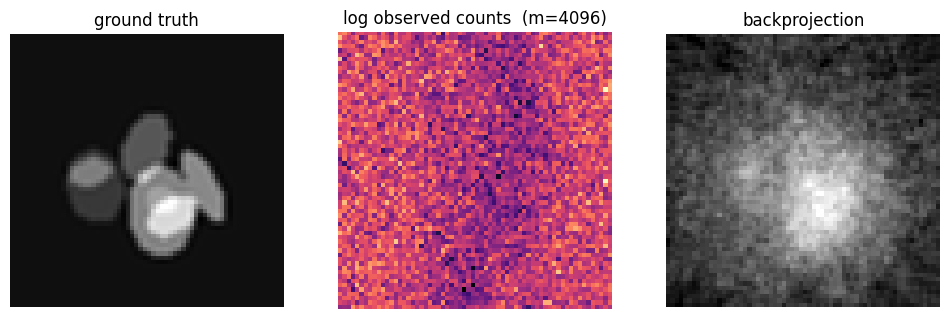

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].imshow(x_true[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1); ax[0].set_title("ground truth")
ax[1].imshow(ct.display_sinogram(y_obs).cpu(), cmap="magma", aspect="auto")
ax[1].set_title(f"log observed counts  (m={ct.obs_dim})")
ax[2].imshow(ct.backproject_from_counts(y_obs)[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
ax[2].set_title("backprojection")
for a in ax: a.axis("off")
if cfg.save_figures: fig.savefig(OUT / "observation.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Methods

Every method obeys one contract:

```python
def method(model, ct, y_obs, cfg, seed) -> torch.Tensor   # (n_samples, 1, H, W) in [-1,1]
```

`ct.reward(x, y_obs)` gives $r$ for a batch of particles; wrap it in
`torch.autograd.grad` for $\nabla r$. Nothing else is problem-specific.

In [8]:
METHODS = {}

def register(name):
    def deco(fn):
        METHODS[name] = fn
        return fn
    return deco


def reward_and_grad(
    self,
    x,
    strength=None,
):
    """Full summed Poisson reward and its image gradient."""

    # Ignore any previously calibrated value.
    likelihood_strength = 1.0

    x = (
        x.detach()
        .requires_grad_(True)
    )

    with torch.enable_grad():
        reward = self.ct.reward(
            x,
            self.y_obs,

            # Sum over all independent Poisson coordinates.
            normalize_by_obs_dim=False,

            # No calibration or likelihood power.
            likelihood_strength=likelihood_strength,
        )

        gradient = torch.autograd.grad(
            reward.sum(),
            x,
        )[0]

    return (
        reward.detach(),
        gradient.detach(),
    )

### 5a. Classical reconstruction (deterministic reference)

FBP with a Hann-windowed ramp filter, plus plain backprojection for contrast.
Unobserved rays are interpolated rather than zero-filled -- a ramp filter reads
zeros as "no attenuation here" and streaks.

In [9]:
@register("FBP")
def method_fbp(model, ct, y_obs, cfg, seed):
    return ct.fbp_from_counts(y_obs, window="hann")


@register("Backprojection")
def method_backprojection(model, ct, y_obs, cfg, seed):
    return ct.backproject_from_counts(y_obs)

### 5b. DPS (Diffusion Posterior Sampling)

Self-contained reverse-SDE sampler with a likelihood-gradient correction at each
step. Step size is normalised by $\|\nabla r\|$, which matters here because
$r$ is order $10^6$ at $m=18432$ and a raw step size would not transfer.

In [10]:
@register("DPS")
def method_dps(model, ct, y_obs, cfg, seed):
    """Chunked DPS using the same VP reverse-SDE convention as the SMC prior.

    Reverse time t increases from cfg.t0 to 1, while the score network receives
    the forward noising time tau=1-t.  Fresh Gaussian noise is injected at every
    numerical step.  The likelihood gradient is taken through the Tweedie
    estimate of x0, as in DPS.
    """
    outputs = []
    H = cfg.img_size

    for start in range(0, cfg.n_samples, cfg.dps_chunk):
        batch = min(cfg.dps_chunk, cfg.n_samples - start)
        generator = torch.Generator(device=DEVICE).manual_seed(seed + 1000003 * start)
        x = torch.randn(batch, 1, H, H, device=DEVICE, generator=generator)

        times = torch.linspace(cfg.t0, cfg.t1, cfg.n_steps + 1, device=DEVICE)
        dt = float(cfg.t1 - cfg.t0) / float(cfg.n_steps)

        for step in range(cfg.n_steps):
            t = times[step]
            t_safe = torch.clamp(t, min=1e-4)
            tau = torch.clamp(1.0 - t_safe,
                              min=cfg.dsm_t_min, max=cfg.dsm_t_max)
            tau_batch = torch.full((batch,), float(tau.item()),
                                   device=DEVICE, dtype=x.dtype)

            # Build the DPS likelihood gradient through the score/Tweedie map.
            x_req = x.detach().requires_grad_(True)
            with torch.enable_grad():
                score_graph = model(x_req, tau_batch)
                sigma2 = 1.0 - t_safe * t_safe
                x0_hat = (x_req + sigma2 * score_graph) / t_safe
                x0_hat = torch.clamp(x0_hat, -cfg.dps_x0_clip, cfg.dps_x0_clip)
                data_loss = -ct.reward(x0_hat, y_obs)
                if cfg.dps_normalize_by_obs_dim:
                    data_loss = data_loss / float(ct.obs_dim)
                guidance_grad = torch.autograd.grad(data_loss.sum(), x_req)[0]

            if cfg.dps_grad_clip is not None:
                grad_norm = guidance_grad.flatten(1).norm(dim=1, keepdim=True)
                scale = torch.clamp(
                    float(cfg.dps_grad_clip) / grad_norm.clamp(min=1e-12),
                    max=1.0,
                ).view(-1, 1, 1, 1)
                guidance_grad = guidance_grad * scale

            # Unconditional reverse-SDE proposal with fresh independent noise.
            with torch.no_grad():
                score = score_graph.detach()
                drift = (x + 2.0 * score) / t_safe
                fresh_noise = torch.randn(x.shape, device=DEVICE, generator=generator)
                x_prior = (
                    x
                    + dt * drift
                    + math.sqrt(dt) * torch.sqrt(2.0 / t_safe) * fresh_noise
                )
                x = x_prior - float(cfg.dps_guidance_scale) * dt * guidance_grad
                x = torch.clamp(x, -cfg.sample_clamp, cfg.sample_clamp)

        outputs.append(torch.clamp(x, -1.0, 1.0).detach().cpu())
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return torch.cat(outputs, dim=0).to(DEVICE)


### 5c. Multilevel SMC (the proposed method)

`ct_smc.py` holds the sampler: multiscale level expansion, base/increment
reverse-SDE simulators, the first-order surrogate
$L_m(x) = r(x) + c_m\eta_m\langle\nabla r(x), \mu_{>m}\rangle$, and branch/kill
resampling. Bodies are ported verbatim from your notebook; only the reward
oracle changed.

**Likelihood tempering is auto-calibrated.** At $m \sim 10^4$ the reward spread
across prior particles is order $10^4$--$10^5$, so raw weights put all mass on
one particle and every level collapses to a single ancestor. The sampler
bisects for the strength that puts level-0 ESS at half the particle count.
Set `auto_calibrate_strength=False` to override.

In [11]:
from ct_smc import run_multilevel_smc_scoreprior, SMCConfig


@register("SMC (ours)")
def method_smc(model, ct, y_obs, cfg, seed):
    # ``none`` means an unscaled first-order tail correction in this notebook.
    tail_path = (
        str(pathlib.Path(cfg.smc_tail_stats).expanduser())
        if cfg.smc_tail_stats
        else ""
    )

    if not tail_path:
        raise FileNotFoundError(
            "CT_TAIL_STATS_PATH is empty, but surrogate_mode='none' uses "
            "the saved tail mean and eta values."
        )

    smc_cfg = SMCConfig(
        img_size=cfg.img_size,
        t0=cfg.t0,
        t1=cfg.t1,
        dsm_t_min=cfg.dsm_t_min,
        dsm_t_max=cfg.dsm_t_max,
        base_noise_mode=cfg.base_noise_mode,
        sample_clamp=cfg.sample_clamp,
        num_smc_levels=cfg.smc_levels,
        num_ref_levels=cfg.smc_ref_levels,
        n_steps_ref_by_level=list(cfg.smc_steps),
        n_steps_smc_by_level=list(cfg.smc_steps[:cfg.smc_levels]),

        # Unscaled first-order tail correction.
        surrogate_mode="inv_m",
        tail_correction_extra_scale=1.0,

        # Load the actual nonzero eta and mu arrays.
        tail_stats_path=tail_path,
        n_ref_tail=cfg.smc_n_ref_tail,
        tail_chunk_size=cfg.smc_tail_chunk,

        # Exact full likelihood: no calibration and no dimension normalization.
        likelihood_strength=1.0,
        auto_calibrate_strength=False,

        n_particles=cfg.n_samples,
        target_population=cfg.n_samples,
        seed=seed,
        surrogate_chunk_size=cfg.reward_chunk,
    )

    print("surrogate mode:", smc_cfg.surrogate_mode)
    print("tail correction extra scale:", smc_cfg.tail_correction_extra_scale)
    print("likelihood strength:", smc_cfg.likelihood_strength)
    print("auto calibration:", smc_cfg.auto_calibrate_strength)
    print("tail-statistics path:", smc_cfg.tail_stats_path)

    assert smc_cfg.surrogate_mode == "inv_m"
    assert smc_cfg.tail_correction_extra_scale == 1.0
    assert smc_cfg.likelihood_strength == 1.0
    #assert smc_cfg.auto_calibrate_strength is False
    assert pathlib.Path(smc_cfg.tail_stats_path).exists()

    out = run_multilevel_smc_scoreprior(
        model,
        ct=ct,
        y_obs=y_obs,
        n_particles=cfg.n_samples,
        seed=seed,
        cfg=smc_cfg,
    )
    globals()["smc_out"] = out
    return out["samples"]


## 6. Run all methods

In [12]:
def psnr(a, b, data_range=2.0):
    mse = torch.mean((a - b) ** 2)
    return float(10.0 * torch.log10(data_range ** 2 / torch.clamp(mse, min=1e-12)))


def method_enabled(name):
    if name == "DPS":
        return cfg.run_dps
    if name == "SMC (ours)":
        return cfg.run_smc
    return True


results = {}
for name, fn in METHODS.items():
    if not method_enabled(name):
        print("skipping", name)
        continue

    print("\n" + "=" * 80)
    print("RUNNING", name)
    print("=" * 80)
    start_time = time.time()
    try:
        samples = fn(score_model, ct, y_obs, cfg, cfg.seed)
    except RuntimeError as exc:
        if "out of memory" in str(exc).lower():
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            raise RuntimeError(
                f"{name} exhausted device memory. Reduce CT_N_SAMPLES, "
                "DPS_CHUNK_SIZE, CT_REWARD_CHUNK, or CT_ANGLE_CHUNK."
            ) from exc
        raise

    elapsed = time.time() - start_time
    mean = samples.mean(0, keepdim=True)
    with torch.no_grad():
        reward = ct.reward(samples, y_obs)
    residuals = ct.residual_summary(samples, y_obs)
    residuals_of_mean = ct.residual_summary(mean, y_obs)

    results[name] = dict(
        samples=samples,
        mean=mean,
        seconds=elapsed,
        rmse=float(torch.sqrt(torch.mean((mean - x_true) ** 2))),
        psnr=psnr(mean, x_true),
        pearson_rms=residuals["pearson_rms_mean"],
        pearson_rms_std=residuals.get("pearson_rms_std", float("nan")),
        deviance=residuals["deviance_per_ray_mean"],
        count_rmse=residuals["count_rmse_mean"],
        pearson_rms_of_mean=residuals_of_mean["pearson_rms_mean"],
        reward_mean=float(reward.mean()),
        post_std=(float(samples.std(0, unbiased=False).mean())
                  if samples.shape[0] > 1 else float("nan")),
        n=int(samples.shape[0]),
    )
    print(f"{name:18s} {elapsed:7.1f}s   rmse={results[name]['rmse']:.4f}   "
          f"psnr={results[name]['psnr']:6.2f}   "
          f"pearson={results[name]['pearson_rms']:6.3f}   "
          f"r={results[name]['reward_mean']:.4e}")

reference_residuals = ct.residual_summary(x_true, y_obs)
_ref = reference_residuals
print(f"\n{'ground truth':18s} {'(reference)':>26s}   "
      f"pearson={_ref['pearson_rms_mean']:6.3f}   (target: ~1.0)")



RUNNING FBP
FBP                    8.8s   rmse=0.7357   psnr=  8.69   pearson= 1.817   r=-6.5919e+03

RUNNING Backprojection
Backprojection         0.0s   rmse=0.4776   psnr= 12.44   pearson= 1.476   r=-4.3670e+03

RUNNING DPS
DPS                  126.6s   rmse=0.2561   psnr= 17.85   pearson= 1.077   r=-2.3792e+03

RUNNING SMC (ours)
surrogate mode: inv_m
tail correction extra scale: 1.0
likelihood strength: 1.0
auto calibration: False
tail-statistics path: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_dsm2000_outputs/score_prior_tail_behavior_stats.npz
loading tail stats: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_dsm2000_outputs/score_prior_tail_behavior_stats.npz
MULTILEVEL SMC  levels: 5  steps: [100, 120, 140, 160, 180]
eta_by_level: ['0.8642', '0.7483', '0.6784', '0.6368', '0.5173']
likelihood_strength: 1.000e+00
surrogate: inv_m  multiplier: 2.441e-04  m: 4096
le

### SMC level diagnostics

ESS per level is the health check. Sustained ESS well below the particle count,
or a unique-ancestor count in the single digits, means the level increments are
too coarse or the tempering is wrong -- not that the method failed.

 level      N       ESS   unique        eta
     1    600       1.0        1     0.8642
     2    600       1.0        1     0.7483
     3    599       2.6       10     0.6784
     4    599       2.7       17     0.6368
     5    605       6.0       39     0.5173


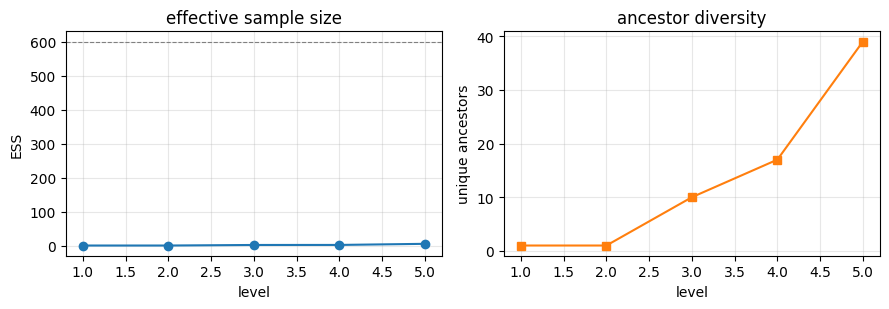

In [13]:
if "smc_out" in globals():
    o = smc_out
    print(f"{'level':>6} {'N':>6} {'ESS':>9} {'unique':>8} {'eta':>10}")
    for i, (n, e, u, et) in enumerate(zip(o["pop_by_level"], o["ess_by_level"],
                                          o["unique_ancestors"], o["eta_by_level"]), 1):
        print(f"{i:>6} {n:>6} {e:>9.1f} {u:>8} {et:>10.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
    lv = range(1, len(o["ess_by_level"]) + 1)
    ax[0].plot(lv, o["ess_by_level"], "o-"); ax[0].set_xlabel("level"); ax[0].set_ylabel("ESS")
    ax[0].axhline(cfg.n_samples, ls="--", c="gray", lw=0.8); ax[0].set_title("effective sample size")
    ax[1].plot(lv, o["unique_ancestors"], "s-", c="C1")
    ax[1].set_xlabel("level"); ax[1].set_ylabel("unique ancestors"); ax[1].set_title("ancestor diversity")
    for a in ax: a.grid(alpha=0.3)
    fig.tight_layout()
    if cfg.save_figures: fig.savefig(OUT / "smc_levels.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Comparison

In [14]:
# pandas is imported in the next cell; no runtime installation is needed.

In [15]:
import pandas as pd
_cols = ["rmse", "psnr", "pearson_rms", "pearson_rms_std", "pearson_rms_of_mean",
         "deviance", "count_rmse", "reward_mean", "post_std", "n", "seconds"]
df = pd.DataFrame({k: {m: v[m] for m in _cols} for k, v in results.items()}).T
df.loc["(ground truth)", "pearson_rms"] = _ref["pearson_rms_mean"]
df.loc["(ground truth)", "deviance"] = _ref["deviance_per_ray_mean"]
df.index.name = "method"
df.to_csv(OUT / "comparison.csv")
df

,rmse,psnr,pearson_rms,pearson_rms_std,pearson_rms_of_mean,deviance,count_rmse,reward_mean,post_std,n,seconds
method,,,,,,,,,,,
FBP,0.735731,8.686213,1.817479,NaN,1.817479,3.218677,55.533539,-6591.850098,NaN,1.0,8.764357
Backprojection,0.477565,12.439955,1.476280,NaN,1.476280,2.132312,45.334881,-4366.974609,NaN,1.0,0.001738
DPS,0.256098,17.852467,1.076963,0.028993,1.039852,1.161711,33.686840,-2379.183838,0.216088,600.0,126.618177
SMC (ours),0.190310,20.431349,1.009724,0.000727,1.008851,1.020326,31.600742,-2089.627441,0.026967,605.0,41.518525
(ground truth),NaN,NaN,1.004097,NaN,NaN,1.008865,NaN,NaN,NaN,NaN,NaN


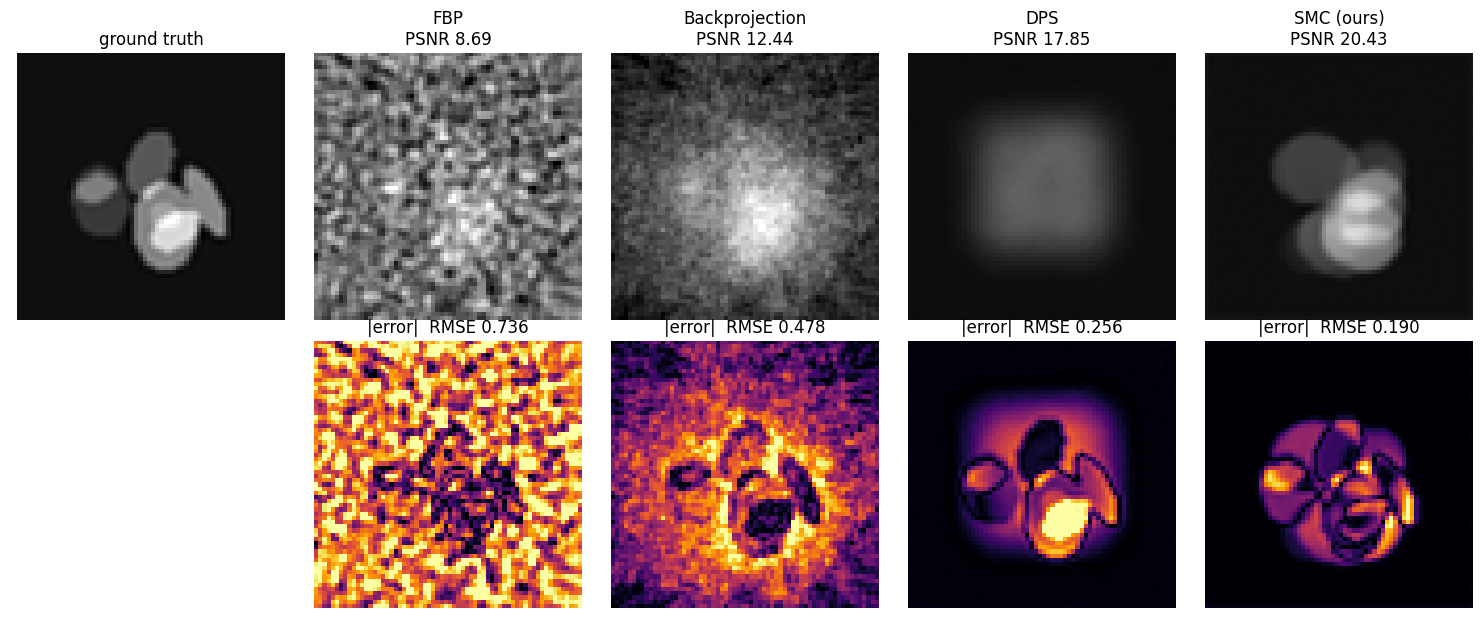

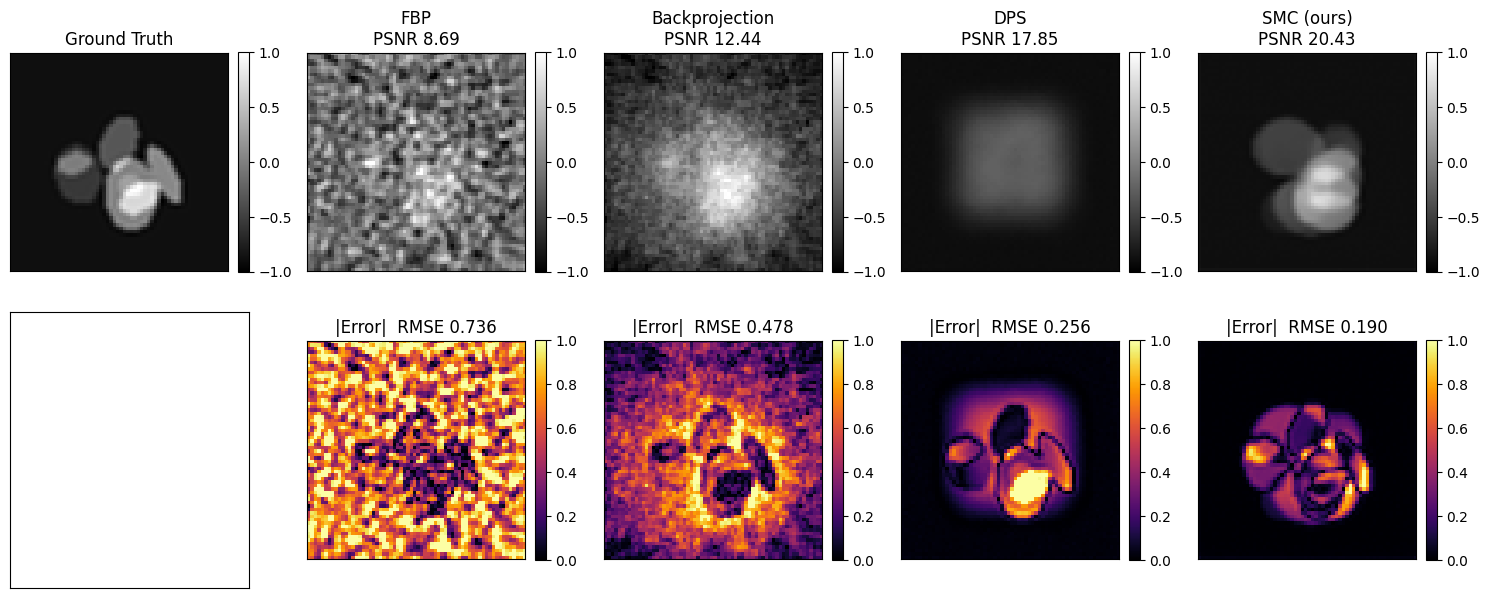

In [16]:
k = len(results)
fig, ax = plt.subplots(2, k + 1, figsize=(3.0 * (k + 1), 6.2))
ax[0, 0].imshow(x_true[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
ax[0, 0].set_title("ground truth"); ax[1, 0].axis("off")
for j, (name, r) in enumerate(results.items(), start=1):
    ax[0, j].imshow(r["mean"][0, 0].detach().cpu(), cmap="gray", vmin=-1, vmax=1)
    ax[0, j].set_title(f"{name}\nPSNR {r['psnr']:.2f}")
    err = (r["mean"] - x_true)[0, 0].abs().detach().cpu()
    im = ax[1, j].imshow(err, cmap="inferno", vmin=0, vmax=1.0)
    ax[1, j].set_title(f"|error|  RMSE {r['rmse']:.3f}")
for a in ax.ravel(): a.axis("off")
fig.tight_layout()
if cfg.save_figures: fig.savefig(OUT / "comparison.png", dpi=150, bbox_inches="tight")
plt.show()

k = len(results)
fig, ax = plt.subplots(2, k + 1, figsize=(3.0 * (k + 1), 6.2))

# Ground truth
im0 = ax[0, 0].imshow(x_true[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
ax[0, 0].set_title("Ground Truth")

# Optional: colorbar for ground truth
fig.colorbar(im0, ax=ax[0, 0], fraction=0.046, pad=0.04)

for j, (name, r) in enumerate(results.items(), start=1):
    # Reconstruction
    im1 = ax[0, j].imshow(
        r["mean"][0, 0].detach().cpu(),
        cmap="gray",
        vmin=-1,
        vmax=1
    )
    ax[0, j].set_title(f"{name}\nPSNR {r['psnr']:.2f}")
    fig.colorbar(im1, ax=ax[0, j], fraction=0.046, pad=0.04)

    # Error map
    err = (r["mean"] - x_true)[0, 0].abs().detach().cpu()
    im2 = ax[1, j].imshow(
        err,
        cmap="inferno",
        vmin=0,
        vmax=1.0
    )
    ax[1, j].set_title(f"|Error|  RMSE {r['rmse']:.3f}")
    fig.colorbar(im2, ax=ax[1, j], fraction=0.046, pad=0.04)

# Hide ticks but keep images and colorbars
for a in ax.ravel():
    a.set_xticks([])
    a.set_yticks([])

fig.tight_layout()

if cfg.save_figures:
    fig.savefig(OUT / "comparison.png", dpi=150, bbox_inches="tight")

plt.show()

## 8. Top-5 MAP particles

The highest-reward particles from each method, which is what the sampler would
report if asked for a point estimate. Ranked by $r(x)$.

Duplicates are suppressed two ways. For SMC, at most one particle per unique
**ancestor lineage** -- otherwise branch/kill fills the top of the ranking with
copies of one successful particle and the panel looks like five identical
images. For methods without lineage information, near-identical images are
collapsed by a rounded content hash. A single image is repeated to fill the row
only when there is genuinely just one distinct particle, and the panel says so.

In [17]:
NUM_MAP_PARTICLES = 5
MAP_DISTINCT_ATOL = 1e-7


def _content_key(x, atol=MAP_DISTINCT_ATOL):
    a = x.detach().cpu().reshape(-1).numpy()
    return (np.round(a / atol).astype(np.int64) if atol else a.astype(np.float32)).tobytes()


@torch.no_grad()
def topk_map_particles(samples, ct, y_obs, k=NUM_MAP_PARTICLES, ancestor_ids=None):
    """Top-k distinct particles by reward. Returns (rewards, samples, meta)."""
    n = int(samples.shape[0])
    if n == 0:
        raise ValueError("empty sample cloud")
    rewards = ct.reward(samples, y_obs).detach()
    order = torch.argsort(rewards, descending=True)

    anc = None
    if ancestor_ids is not None:
        anc = np.asarray(ancestor_ids).reshape(-1)
        if len(anc) != n:
            print(f"  ancestor_ids length {len(anc)} != {n}; using content hashing")
            anc = None

    picked, seen_anc, seen_key = [], set(), set()
    for i in order.tolist():
        if anc is not None:
            a = int(anc[i])
            if a in seen_anc:
                continue
            seen_anc.add(a)
        key = _content_key(samples[i])
        if key in seen_key:
            continue
        seen_key.add(key)
        picked.append(i)
        if len(picked) >= k:
            break

    repeated = False
    if len(picked) == 1 and k > 1:
        picked = picked * k              # only ever repeat a genuine singleton
        repeated = True

    idx = torch.as_tensor(picked, dtype=torch.long, device=samples.device)
    meta = dict(n_distinct=len(set(picked)), n_displayed=len(picked),
                repeated_single=repeated,
                n_unique_ancestors=int(len(np.unique(anc))) if anc is not None else None)
    return rewards[idx], samples[idx], meta

DPS                5 distinct
SMC (ours)         1 distinct, 1 unique lineages  (single particle repeated)


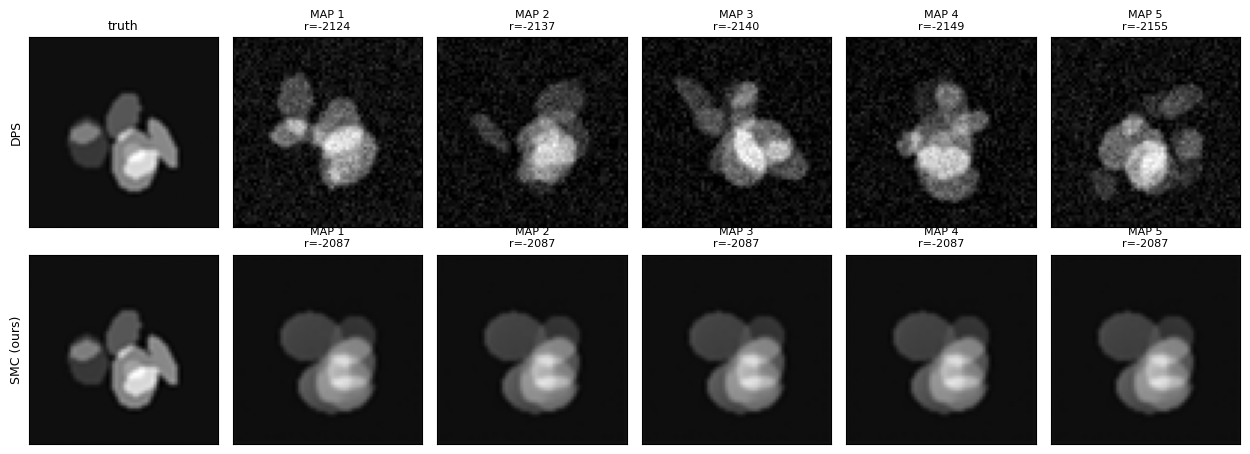

In [18]:
map_results = {}
for name, r in results.items():
    if r["samples"].shape[0] < 2:
        continue                      # deterministic methods have nothing to rank
    anc = smc_out.get("ancestors") if (name.startswith("SMC") and "smc_out" in globals()) else None
    rw, mp, meta = topk_map_particles(r["samples"], ct, y_obs, ancestor_ids=anc)
    map_results[name] = (rw, mp, meta)
    tag = "  (single particle repeated)" if meta["repeated_single"] else ""
    anc_tag = f", {meta['n_unique_ancestors']} unique lineages" if meta["n_unique_ancestors"] else ""
    print(f"{name:18s} {meta['n_distinct']} distinct{anc_tag}{tag}")

if map_results:
    nrow = len(map_results)
    fig, ax = plt.subplots(nrow, NUM_MAP_PARTICLES + 1,
                           figsize=(2.1 * (NUM_MAP_PARTICLES + 1), 2.3 * nrow),
                           squeeze=False)
    for i, (name, (rw, mp, meta)) in enumerate(map_results.items()):
        ax[i, 0].imshow(x_true[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
        ax[i, 0].set_ylabel(name, fontsize=9)
        ax[i, 0].set_title("truth" if i == 0 else "", fontsize=9)
        for j in range(NUM_MAP_PARTICLES):
            a = ax[i, j + 1]
            if j < mp.shape[0]:
                a.imshow(mp[j, 0].detach().cpu(), cmap="gray", vmin=-1, vmax=1)
                a.set_title(f"MAP {j+1}\nr={float(rw[j]):.4g}", fontsize=8)
            else:
                a.set_visible(False)
        for a in ax[i]:
            a.set_xticks([]); a.set_yticks([])
    fig.tight_layout()
    if cfg.save_figures:
        fig.savefig(OUT / "top5_map_particles.png", dpi=150, bbox_inches="tight")
    plt.show()

### Measurement-space residuals

`rmse` and `psnr` need a ground truth you will not have on real data.
`pearson_rms` does not -- it asks whether a sample explains the observed counts,
which is exactly what the likelihood constrains.

Because the noise is Poisson with known rate, it is self-normalising:
$\sqrt{\frac{1}{m}\sum_i (y_i-\lambda_i)^2/\lambda_i} \approx 1$ for a sample from
the true posterior. Above 1 means underfitting; **below 1 means the sample is
fitting the noise realisation**, which image-space RMSE will not reveal. Read it
against the `(ground truth)` row.

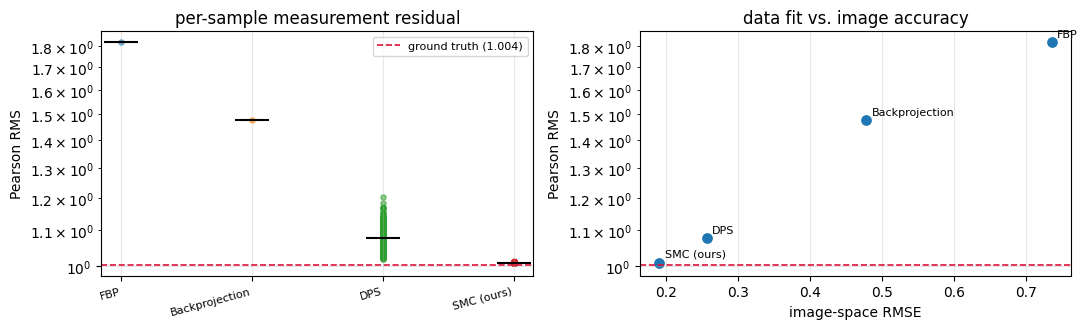

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
names = list(results.keys())

for i, name in enumerate(names):
    pr = ct.measurement_residuals(results[name]["samples"], y_obs)["pearson_rms"]
    ax[0].scatter([i] * len(pr), pr.cpu(), s=14, alpha=0.55)
    ax[0].scatter([i], [float(pr.mean())], marker="_", s=600, c="k", zorder=3)
ax[0].axhline(_ref["pearson_rms_mean"], ls="--", c="crimson", lw=1.2,
              label=f"ground truth ({_ref['pearson_rms_mean']:.3f})")
ax[0].set_xticks(range(len(names)))
ax[0].set_xticklabels(names, rotation=15, ha="right", fontsize=8)
ax[0].set_ylabel("Pearson RMS"); ax[0].set_yscale("log")
ax[0].set_title("per-sample measurement residual"); ax[0].legend(fontsize=8)

ax[1].scatter([results[n]["rmse"] for n in names],
              [results[n]["pearson_rms"] for n in names], s=45)
for n in names:
    ax[1].annotate(n, (results[n]["rmse"], results[n]["pearson_rms"]),
                   fontsize=8, xytext=(4, 4), textcoords="offset points")
ax[1].axhline(_ref["pearson_rms_mean"], ls="--", c="crimson", lw=1.2)
ax[1].set_xlabel("image-space RMSE"); ax[1].set_ylabel("Pearson RMS")
ax[1].set_yscale("log"); ax[1].set_title("data fit vs. image accuracy")
for a in ax: a.grid(alpha=0.3)
fig.tight_layout()
if cfg.save_figures: fig.savefig(OUT / "residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Posterior sampling quality

Four axes. No single number separates a good sampler from a bad one -- a method
can ace any one while failing badly on another, so read them together.

| axis | metric | target | what it catches |
|---|---|---|---|
| data fit | `chi2_per_ray` | **1.0**, not 0 | `< 1` = fitted the noise; `>> 1` = inconsistent with the counts |
| prior typicality | `dsm_z` | ~0 | likelihood dragged samples off the learned manifold |
| diversity | `participation_ratio` | large | `0` = collapsed to one image |
| calibration | `contraction_ratio` | 1.0 | `< 1` = overconfident spread |

`contraction_ratio` is RMS(posterior sd) / RMS(mean - truth): does the reported
uncertainty match the actual error? It is the one that catches a sampler
looking healthy on the other three and still lying about its confidence.

`participation_ratio` is the effective number of directions the cloud explores,
from the covariance spectrum. It beats a pixel standard deviation, which stays
large even when the cloud is N copies of two images.

`dsm_z` needs a **trained** prior. With a random-init checkpoint it is noise.

In [20]:
if cfg.run_posterior_quality:
    import ct_metrics as metrics
    importlib.reload(metrics)

    prior_ref = torch.cat([
        common.sample_cylinder_image(i, cfg.img_size, seed=999, device=DEVICE)
        for i in range(16)
    ])

    reports = {}
    for name, result in results.items():
        if result["samples"].shape[0] < 2:
            continue
        reports[name] = metrics.posterior_report(
            ct, score_model, result["samples"], y_obs, x_true,
            prior_ref, seed=cfg.seed)

    print(metrics.format_report(reports))
else:
    reports = {}
    print("posterior-quality score-model diagnostics skipped in smoke mode; "
          "set CT_RUN_POSTERIOR_QUALITY=1 to enable them")


metric                         DPS  SMC (ours)   target
----------------------------------------------------------
chi2_per_ray                 1.161        1.02   = 1  (< 1 means the noise was fitted)
chi2_z                       7.272      0.8844   |z| < ~3
dsm_z                        6.669      -1.347   ~0  (large = off the prior manifold)
participation_ratio          25.34       3.927   large  (1.0 = collapsed)
distinct_fraction                1     0.06446   -> 1
contraction_ratio            1.061      0.2762   = 1  (< 1 = overconfident)
coverage_90                 0.9751      0.2307   -> 0.90


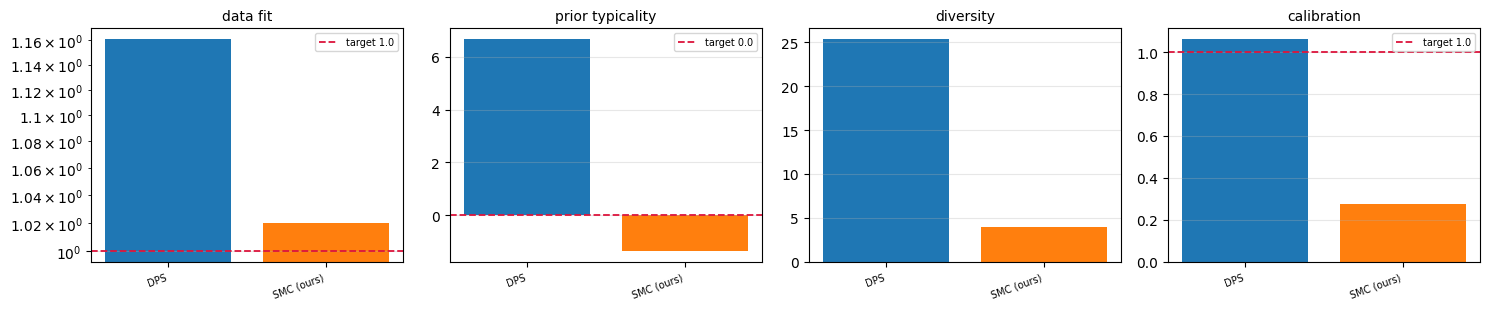

In [21]:
if reports:
    fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
    names = list(reports)
    panels = [("chi2_per_ray", 1.0, "data fit", True),
              ("dsm_z", 0.0, "prior typicality", False),
              ("participation_ratio", None, "diversity", False),
              ("contraction_ratio", 1.0, "calibration", False)]
    for axis, (key, target, title, logy) in zip(ax, panels):
        values = [reports[name][key] for name in names]
        axis.bar(range(len(names)), values,
                 color=[f"C{i}" for i in range(len(names))])
        if target is not None:
            axis.axhline(target, ls="--", c="crimson", lw=1.3,
                         label=f"target {target}")
            axis.legend(fontsize=7)
        if logy and min(values) > 0:
            axis.set_yscale("log")
        axis.set_xticks(range(len(names)))
        axis.set_xticklabels(names, rotation=20, ha="right", fontsize=7)
        axis.set_title(title, fontsize=10)
        axis.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    if cfg.save_figures:
        fig.savefig(OUT / "posterior_quality.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("posterior-quality plot skipped")


### Simulation-based calibration (optional, expensive)

The four axes above can fail to reject a bad sampler. SBC can actually certify
one: draw $x^\star$ from the prior, simulate $y$, sample, and record the rank of
$x^\star$ among the samples. Under exact posterior sampling that rank is
**uniform**. A U-shaped histogram means the posterior is too narrow, a peaked
one too wide, a skewed one biased.

Costs `n_trials` full sampler runs, so use reduced settings. Set `RUN_SBC=True`.

In [22]:
RUN_SBC = False        # set True to run; costs n_trials full sampler runs

if RUN_SBC:
    import copy
    import ct_metrics as metrics

    def _prior_draw(s):
        return common.sample_cylinder_image(
            0, cfg.img_size, seed=s, device=DEVICE
        )

    def _sampler(y_k, n, s):
        cfg_sbc = copy.copy(cfg)
        cfg_sbc.n_samples = int(n)
        return METHODS["SMC (ours)"](
            score_model, ct, y_k, cfg_sbc, s
        )

    sbc = metrics.simulation_based_calibration(
        ct, _sampler, _prior_draw,
        n_trials=20, n_samples=16, seed=cfg.seed
    )
    print(
        f"SBC: {sbc['n_trials']} trials, "
        f"chi2={sbc['chi2']:.2f}, p={sbc['p_value']:.3f}"
    )
    print("  p > 0.05 is consistent with correct sampling (not proof of it)")

    fig, a = plt.subplots(figsize=(4.6, 3.0))
    a.bar(range(len(sbc["histogram"])), sbc["histogram"])
    a.axhline(
        len(sbc["ranks"]) / len(sbc["histogram"]),
        ls="--", c="crimson", label="uniform"
    )
    a.set_xlabel("rank bin")
    a.set_ylabel("count")
    a.legend(fontsize=8)
    a.set_title("SBC rank histogram")
    fig.tight_layout()
    if cfg.save_figures:
        fig.savefig(OUT / "sbc_ranks.png", dpi=150, bbox_inches="tight")
    plt.show()


In [23]:
import json

payload = {
    "fingerprint": ct.fingerprint(y_obs=y_obs, x_true=x_true),
    "config": {key: (str(value) if isinstance(value, pathlib.Path) else value)
               for key, value in cfg.__dict__.items()},
    "regime": rep,
    "ground_truth_residuals": _ref,
    "posterior_quality": {
        method: {metric: value for metric, value in report.items()}
        for method, report in reports.items()
    },
    "results": {
        method: {metric: values[metric] for metric in _cols}
        for method, values in results.items()
    },
}

with open(OUT / "run.json", "w", encoding="utf-8") as handle:
    json.dump(payload, handle, indent=2)
print("wrote", OUT / "run.json")


wrote ct_poisson_outputs/run.json


FLEXIBLE TOP-5 MAP PARTICLES FOR EACH SMC LEVEL
Particle source: smc_out['samples_by_level'] (post-resampling population)
Selection rule: show distinct particles when available; otherwise repeat MAPs
SMC level  1: 1 distinct particle(s) among 600 stored particles; showing 5 panels.
   All stored particles are identical (or numerically indistinguishable); MAP 1 is repeated.
   rank  1 | reward = -2212.21 | root=300
   rank  2 | reward = -2212.21 | root=300 | repeat of distinct #1
   rank  3 | reward = -2212.21 | root=300 | repeat of distinct #1
   rank  4 | reward = -2212.21 | root=300 | repeat of distinct #1
   rank  5 | reward = -2212.21 | root=300 | repeat of distinct #1
SMC level  2: 1 distinct particle(s) among 600 stored particles; showing 5 panels.
   All stored particles are identical (or numerically indistinguishable); MAP 1 is repeated.
   rank  1 | reward = -2127.96 | root=300
   rank  2 | reward = -2127.96 | root=300 | repeat of distinct #1
   rank  3 | reward = -2127.96 | r

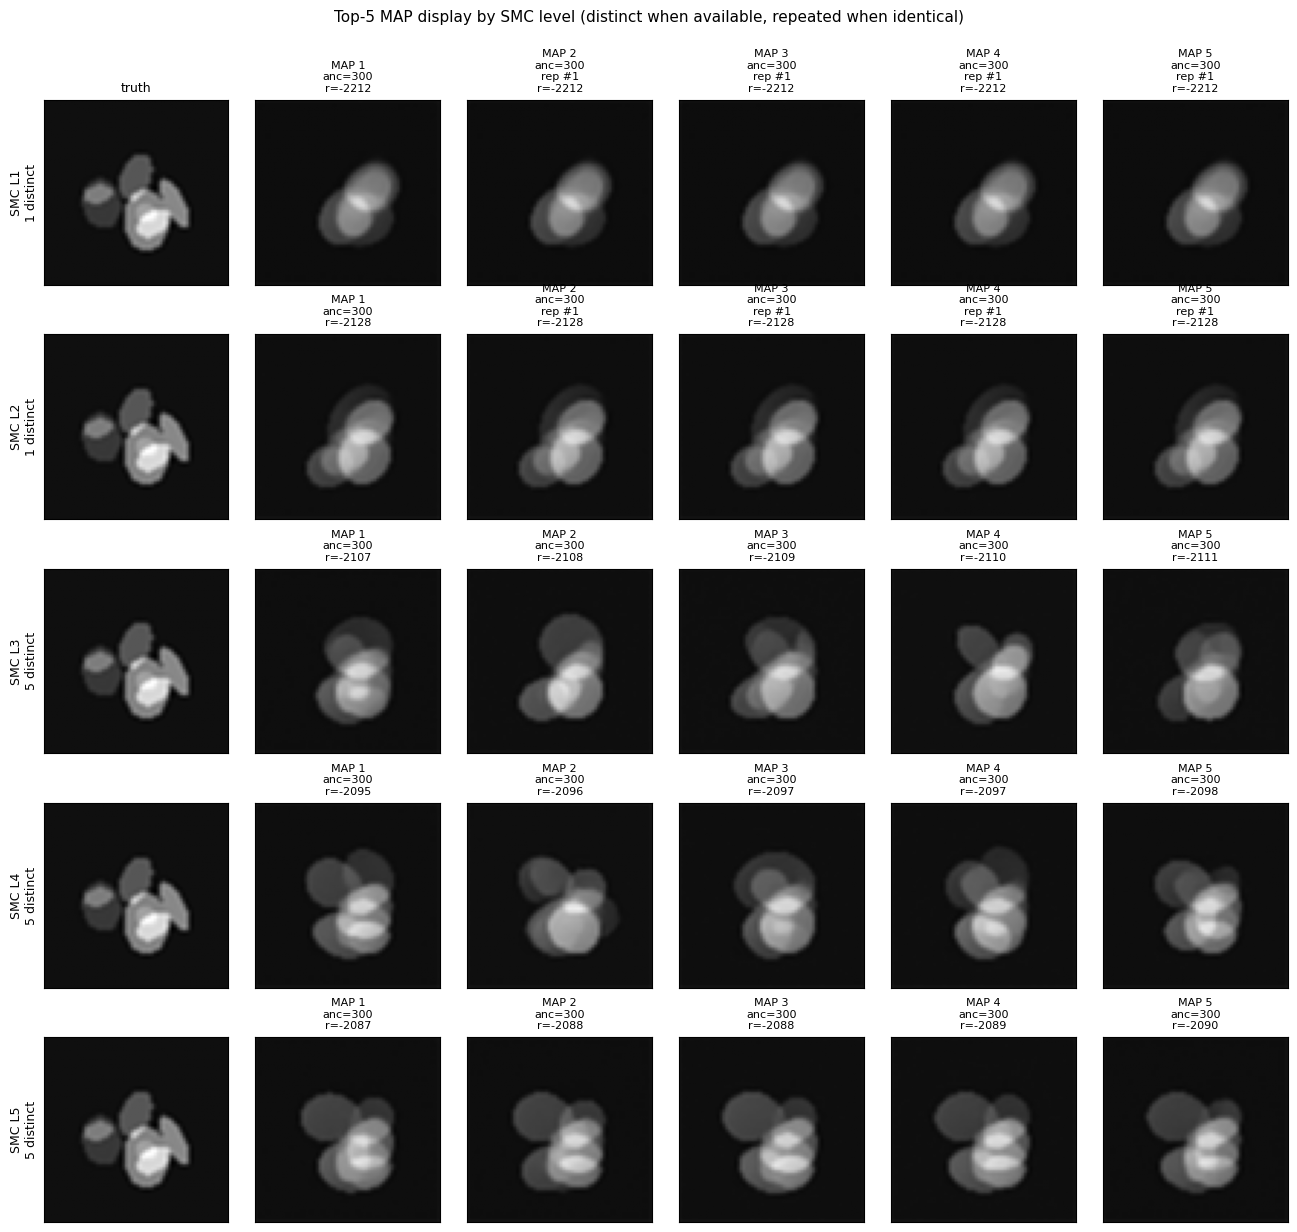

In [24]:
# ============================================================
# Flexible Top-5 MAP display for each SMC level (levels 1--5)
# - Prefer distinct particles when they exist.
# - If fewer than 5 distinct particles exist, repeat the best one(s)
#   so that each level always shows 5 MAP panels.
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

NUM_MAP_PARTICLES = int(globals().get("NUM_MAP_PARTICLES", 5))
MAP_REWARD_CHUNK_SIZE = int(globals().get("MAP_REWARD_CHUNK_SIZE", 16))
MAP_DISTINCT_RMSE_TOL = float(globals().get("MAP_DISTINCT_RMSE_TOL", 1e-7))

if "smc_out" not in globals():
    raise NameError("smc_out not found. Run the SMC method first.")

# Avoid `a or b` here: tensors/lists may not safely convert to bool.
samples_by_level = None
samples_key = None
for key in ("samples_by_level", "level_samples", "particles_by_level"):
    value = smc_out.get(key, None)
    if value is not None:
        samples_by_level = value
        samples_key = key
        break

if samples_by_level is None:
    raise KeyError(
        "Could not find per-level samples in smc_out. "
        "Expected one of: 'samples_by_level', 'level_samples', or "
        "'particles_by_level'."
    )

# Optional labels only for printing. They do NOT restrict selection.
root_ancestors_by_level = smc_out.get("ancestors_by_level", None)
local_branch_ids_by_level = smc_out.get("local_branch_ids_by_level", None)


def _as_image_batch(samples):
    if not torch.is_tensor(samples):
        samples = torch.as_tensor(samples)
    if samples.ndim == 3:
        samples = samples[:, None, :, :]
    if samples.ndim != 4:
        raise ValueError(
            "Expected level samples with shape (N,H,W) or (N,1,H,W); "
            f"received {tuple(samples.shape)}."
        )
    return samples


@torch.no_grad()
def _reward_in_chunks(samples, ct, y_obs, chunk_size=MAP_REWARD_CHUNK_SIZE):
    reward_parts = []
    reward_device = y_obs.device

    for sample_chunk in samples.split(max(1, int(chunk_size)), dim=0):
        reward_parts.append(
            ct.reward(sample_chunk.to(reward_device), y_obs)
            .detach()
            .to("cpu", dtype=torch.float64)
        )

    return torch.cat(reward_parts, dim=0)


@torch.no_grad()
def _pairwise_rmse(x, y):
    return torch.sqrt(torch.mean((x.float() - y.float()) ** 2))


@torch.no_grad()
def topk_map_flexible(
    samples,
    ct,
    y_obs,
    k=NUM_MAP_PARTICLES,
    distinct_tol=MAP_DISTINCT_RMSE_TOL,
):
    """Return exactly k display particles.

    First collect up to k reward-ranked, visually distinct particles.
    If fewer than k distinct particles exist, repeat the selected particles
    cyclically. When only one unique particle exists, MAP 1 is repeated.
    """
    samples = _as_image_batch(samples)
    n_candidates = int(samples.shape[0])

    if n_candidates == 0:
        raise ValueError("The level sample cloud is empty.")

    rewards = _reward_in_chunks(samples, ct, y_obs)
    order = torch.argsort(rewards, descending=True).tolist()

    distinct_indices = []

    for candidate_index in order:
        candidate = samples[candidate_index]
        is_duplicate = False

        for previous_index in distinct_indices:
            rmse = _pairwise_rmse(candidate, samples[previous_index])
            if float(rmse.detach().cpu()) <= float(distinct_tol):
                is_duplicate = True
                break

        if is_duplicate:
            continue

        distinct_indices.append(candidate_index)

        if len(distinct_indices) >= int(k):
            break

    if not distinct_indices:
        distinct_indices = [int(order[0])]

    # Always output exactly k display slots.
    display_indices = []
    repeat_of = []

    for j in range(int(k)):
        distinct_position = j % len(distinct_indices)
        display_indices.append(distinct_indices[distinct_position])
        repeat_of.append(distinct_position + 1)

    reward_index = torch.as_tensor(display_indices, dtype=torch.long)
    sample_index = torch.as_tensor(
        display_indices,
        dtype=torch.long,
        device=samples.device,
    )

    meta = {
        "n_candidates": n_candidates,
        "n_distinct": len(distinct_indices),
        "n_display": int(k),
        "distinct_indices": distinct_indices,
        "display_indices": display_indices,
        "repeat_of": repeat_of,
        "all_identical": len(distinct_indices) == 1,
    }

    return rewards[reward_index], samples[sample_index], meta


def _safe_label_array(label_list, level_idx, n_expected):
    if label_list is None or len(label_list) < level_idx:
        return None

    arr = np.asarray(label_list[level_idx - 1]).reshape(-1)

    if len(arr) != n_expected:
        return None

    return arr


level_map_results = {}

print("=" * 100)
print("FLEXIBLE TOP-5 MAP PARTICLES FOR EACH SMC LEVEL")
print(f"Particle source: smc_out[{samples_key!r}] (post-resampling population)")
print("Selection rule: show distinct particles when available; otherwise repeat MAPs")
print("=" * 100)

for ell, level_samples in enumerate(samples_by_level, start=1):
    if level_samples is None:
        continue

    level_samples = _as_image_batch(level_samples)

    if int(level_samples.shape[0]) < 1:
        continue

    rw, mp, meta = topk_map_flexible(
        level_samples,
        ct,
        y_obs,
        k=NUM_MAP_PARTICLES,
        distinct_tol=MAP_DISTINCT_RMSE_TOL,
    )

    root_labels = _safe_label_array(
        root_ancestors_by_level,
        ell,
        meta["n_candidates"],
    )
    branch_labels = _safe_label_array(
        local_branch_ids_by_level,
        ell,
        meta["n_candidates"],
    )

    display_root_labels = []
    display_branch_labels = []

    for particle_index in meta["display_indices"]:
        display_root_labels.append(
            int(root_labels[particle_index]) if root_labels is not None else None
        )
        display_branch_labels.append(
            int(branch_labels[particle_index]) if branch_labels is not None else None
        )

    meta["display_root_labels"] = display_root_labels
    meta["display_branch_labels"] = display_branch_labels

    level_map_results[ell] = (rw, mp, meta)

    print(
        f"SMC level {ell:>2d}: {meta['n_distinct']} distinct particle(s) among "
        f"{meta['n_candidates']} stored particles; showing "
        f"{NUM_MAP_PARTICLES} panels."
    )

    if meta["all_identical"]:
        print(
            "   All stored particles are identical (or numerically "
            "indistinguishable); MAP 1 is repeated."
        )
    elif meta["n_distinct"] < NUM_MAP_PARTICLES:
        print(
            f"   Only {meta['n_distinct']} distinct particles were found; "
            "remaining panels are repeated cyclically."
        )
    else:
        print("   At least five distinct particles were found; all panels are distinct.")

    for j in range(NUM_MAP_PARTICLES):
        repeat_note = ""
        if meta["repeat_of"][j] != j + 1:
            repeat_note = f" | repeat of distinct #{meta['repeat_of'][j]}"

        root_note = ""
        branch_note = ""

        if meta["display_root_labels"][j] is not None:
            root_note = f" | root={meta['display_root_labels'][j]}"

        if meta["display_branch_labels"][j] is not None:
            branch_note = f" | branch={meta['display_branch_labels'][j]}"

        print(
            f"   rank {j + 1:>2d} | reward = {float(rw[j]):.6g}"
            f"{root_note}{branch_note}{repeat_note}"
        )

# ------------------------------------------------------------
# Plot truth + exactly five MAP panels for each level
# ------------------------------------------------------------
if level_map_results:
    nrow = len(level_map_results)

    fig, ax = plt.subplots(
        nrow,
        NUM_MAP_PARTICLES + 1,
        figsize=(2.2 * (NUM_MAP_PARTICLES + 1), 2.45 * nrow),
        squeeze=False,
    )

    level_items = sorted(level_map_results.items(), key=lambda item: item[0])

    for row, (ell, (rw, mp, meta)) in enumerate(level_items):
        ax[row, 0].imshow(
            x_true[0, 0].detach().cpu(),
            cmap="gray",
            vmin=-1,
            vmax=1,
        )
        ax[row, 0].set_ylabel(
            f"SMC L{ell}\n{meta['n_distinct']} distinct",
            fontsize=9,
        )
        ax[row, 0].set_title("truth" if row == 0 else "", fontsize=9)

        for rank in range(NUM_MAP_PARTICLES):
            axis = ax[row, rank + 1]
            axis.imshow(
                mp[rank, 0].detach().cpu(),
                cmap="gray",
                vmin=-1,
                vmax=1,
            )

            repeat_note = ""
            if meta["repeat_of"][rank] != rank + 1:
                repeat_note = f"\nrep #{meta['repeat_of'][rank]}"

            aux_note = ""
            if meta["display_branch_labels"][rank] is not None:
                aux_note = f"\nbr={meta['display_branch_labels'][rank]}"
            elif meta["display_root_labels"][rank] is not None:
                aux_note = f"\nanc={meta['display_root_labels'][rank]}"

            axis.set_title(
                f"MAP {rank + 1}{aux_note}{repeat_note}"
                f"\nr={float(rw[rank]):.4g}",
                fontsize=8,
            )

        for axis in ax[row]:
            axis.set_xticks([])
            axis.set_yticks([])

    fig.suptitle(
        "Top-5 MAP display by SMC level "
        "(distinct when available, repeated when identical)",
        fontsize=11,
        y=1.002,
    )
    fig.tight_layout()

    if getattr(cfg, "save_figures", False):
        figure_path = OUT / "smc_levels_top5_flexible_map_particles.png"
        fig.savefig(figure_path, dpi=150, bbox_inches="tight")
        print("saved", figure_path)

    plt.show()
else:
    print("No per-level MAP results were produced.")


In [30]:
# ============================================================
# Top-5 particles with largest empirical weight
# (not MAP)
# ============================================================

from collections import Counter

print("=" * 100)
print("TOP-5 PARTICLES WITH LARGEST EMPIRICAL WEIGHT")
print("=" * 100)

for ell, level_samples in enumerate(samples_by_level):

    level_samples = _as_image_batch(level_samples)
    N = level_samples.shape[0]

    samples_cpu = level_samples.detach().cpu()

    # --------------------------------------------------------
    # exact duplicate signatures
    # --------------------------------------------------------
    keys = [
        samples_cpu[i].contiguous().reshape(-1).numpy().tobytes()
        for i in range(N)
    ]

    duplicate_counter = Counter(keys)

    # representative particle for every unique image
    representative = {}
    for idx, key in enumerate(keys):
        if key not in representative:
            representative[key] = idx

    particle_info = []

    ancestor_ids = None
    if (
        ancestors_by_level is not None
        and len(ancestors_by_level) > ell
    ):
        ancestor_ids = np.asarray(
            ancestors_by_level[ell]
        )

    for key, dup_count in duplicate_counter.items():

        idx = representative[key]

        ancestor = None
        lineage_count = None
        lineage_weight = None

        if ancestor_ids is not None:
            ancestor = int(ancestor_ids[idx])

            lineage_count = int(
                np.sum(ancestor_ids == ancestor)
            )

            lineage_weight = (
                lineage_count / float(N)
            )

        particle_info.append({
            "index": idx,
            "duplicate_count": dup_count,
            "particle_weight": dup_count / float(N),
            "ancestor": ancestor,
            "lineage_count": lineage_count,
            "lineage_weight": lineage_weight,
        })

    # --------------------------------------------------------
    # sort by empirical weight
    # --------------------------------------------------------
    particle_info = sorted(
        particle_info,
        key=lambda d: d["particle_weight"],
        reverse=True,
    )

    top5 = particle_info[:5]

    print("\n" + "-" * 100)
    print(f"SMC LEVEL {ell+1}")
    print("-" * 100)

    for rank, p in enumerate(top5, start=1):

        print(
            f"rank {rank} | particle={p['index']}"
        )

        print(
            f"       | duplicates={p['duplicate_count']}/{N}"
        )

        print(
            f"       | particle_weight={p['particle_weight']:.6f}"
        )

        if p["ancestor"] is not None:

            print(
                f"       | ancestor={p['ancestor']}"
            )

            print(
                f"       | lineage_count={p['lineage_count']}/{N}"
            )

            print(
                f"       | lineage_weight={p['lineage_weight']:.6f}"
            )

TOP-5 PARTICLES WITH LARGEST EMPIRICAL WEIGHT

----------------------------------------------------------------------------------------------------
SMC LEVEL 1
----------------------------------------------------------------------------------------------------
rank 1 | particle=0
       | duplicates=600/600
       | particle_weight=1.000000
       | ancestor=300
       | lineage_count=600/600
       | lineage_weight=1.000000

----------------------------------------------------------------------------------------------------
SMC LEVEL 2
----------------------------------------------------------------------------------------------------
rank 1 | particle=0
       | duplicates=600/600
       | particle_weight=1.000000
       | ancestor=300
       | lineage_count=600/600
       | lineage_weight=1.000000

----------------------------------------------------------------------------------------------------
SMC LEVEL 3
--------------------------------------------------------------------------